K-Means

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_circles
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

In [2]:
df = pd.read_csv('bank+marketing/bank-additional/bank-additional/bank-additional-full.csv',
                 sep=';', na_values=[''], quotechar='"')

df = df.drop(columns=['y'], errors='ignore')

categorical_cols = ['job', 'marital', 'education', 'default',
                    'housing', 'loan', 'contact', 'month',
                    'day_of_week', 'poutcome']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [3]:
df.head(5)

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,...,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,56,261,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,True,False,False,False,True,False
1,57,149,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,True,False,False,False,True,False
2,37,226,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,True,False,False,False,True,False
3,40,151,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,True,False,False,False,True,False
4,56,307,1,999,0,1.1,93.994,-36.4,4.857,5191.0,...,True,False,False,False,True,False,False,False,True,False


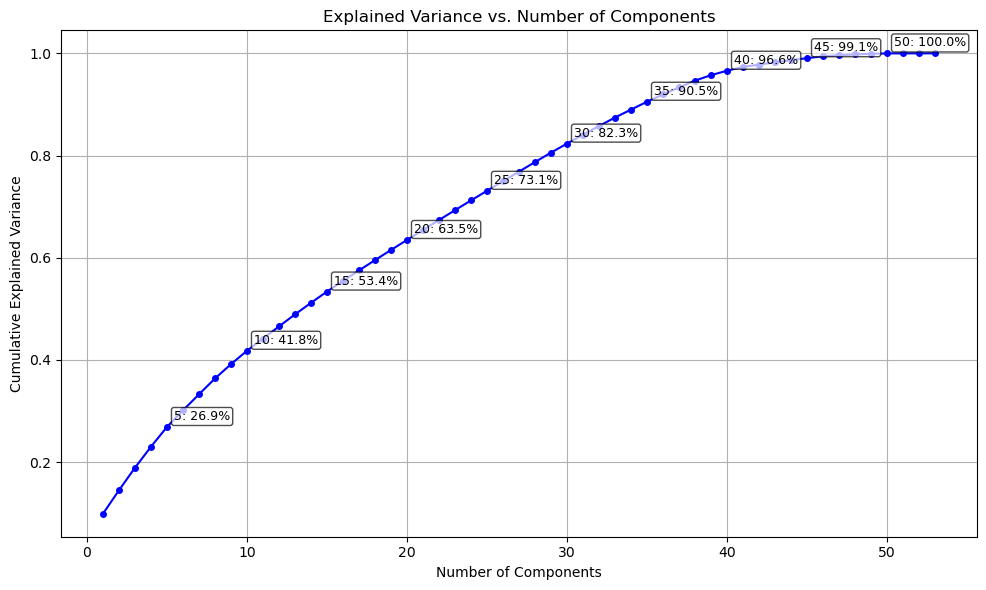

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

pca = PCA().fit(X_scaled)
cum_var = np.cumsum(pca.explained_variance_ratio_)
n_components = len(cum_var)
components = np.arange(1, n_components + 1)

plt.figure(figsize=(10, 6))
plt.plot(components, cum_var, marker='o', markersize=4, linestyle='-', color='b')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs. Number of Components')
plt.grid(True)

step = 5
indices = range(step - 1, n_components, step)
for i in indices:
    x = components[i]
    y = cum_var[i]
    label = f'{x}: {y:.1%}'
    plt.annotate(label,
                 xy=(x, y),
                 xytext=(5, 5),
                 textcoords='offset points',
                 fontsize=9,
                 bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

plt.tight_layout()
plt.show()

In [5]:
n_pca = 45
pca_45 = PCA(n_components=n_pca, random_state=42)
X_pca = pca_45.fit_transform(X_scaled)

sample_size = min(5000, X_pca.shape[0])
np.random.seed(42)
sample_idx = np.random.choice(X_pca.shape[0], size=sample_size, replace=False)
X_sample = X_pca[sample_idx]

K_range = range(2, 41)
silhouette_scores = []
best_k = None
best_score = -1

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_pca)
    labels_sample = kmeans.predict(X_sample)
    score = silhouette_score(X_sample, labels_sample)
    silhouette_scores.append(score)
    print(f"K = {k:2d} | Silhouette = {score:.4f}")

    if score > best_score:
        best_score = score
        best_k = k

print(f"\nОптимальное K = {best_k} (силуэт = {best_score:.4f})")

K =  2 | Silhouette = 0.3313
K =  3 | Silhouette = 0.0374
K =  4 | Silhouette = 0.0524
K =  5 | Silhouette = 0.0588
K =  6 | Silhouette = 0.0709
K =  7 | Silhouette = 0.0832
K =  8 | Silhouette = 0.0759
K =  9 | Silhouette = 0.0755
K = 10 | Silhouette = 0.0820
K = 11 | Silhouette = 0.0809
K = 12 | Silhouette = 0.0912
K = 13 | Silhouette = 0.0949
K = 14 | Silhouette = 0.0980
K = 15 | Silhouette = 0.1052
K = 16 | Silhouette = 0.1003
K = 17 | Silhouette = 0.1056
K = 18 | Silhouette = 0.1127
K = 19 | Silhouette = 0.1169
K = 20 | Silhouette = 0.1172
K = 21 | Silhouette = 0.1266
K = 22 | Silhouette = 0.1291
K = 23 | Silhouette = 0.1220
K = 24 | Silhouette = 0.1270
K = 25 | Silhouette = 0.1279
K = 26 | Silhouette = 0.1215
K = 27 | Silhouette = 0.1234
K = 28 | Silhouette = 0.1268
K = 29 | Silhouette = 0.1256
K = 30 | Silhouette = 0.1171
K = 31 | Silhouette = 0.1146
K = 32 | Silhouette = 0.1152
K = 33 | Silhouette = 0.1176
K = 34 | Silhouette = 0.1249
K = 35 | Silhouette = 0.1238
K = 36 | Silho

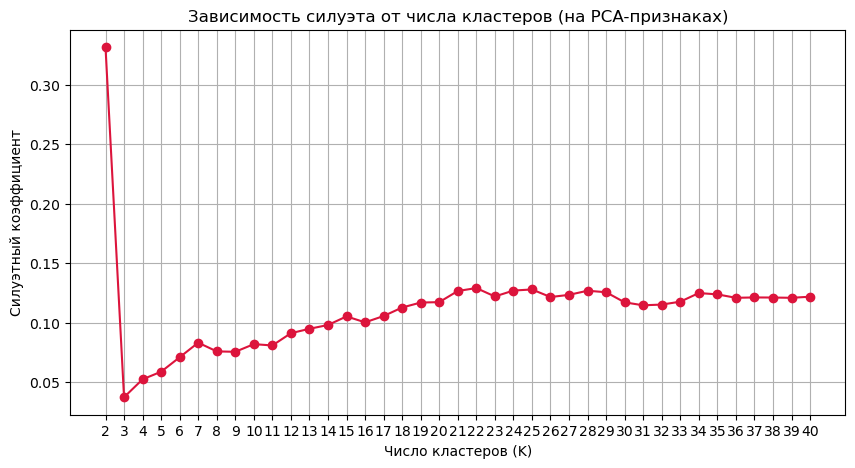

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(K_range, silhouette_scores, marker='o', color='crimson')
plt.xlabel('Число кластеров (K)')
plt.ylabel('Силуэтный коэффициент')
plt.title('Зависимость силуэта от числа кластеров (на PCA-признаках)')
plt.xticks(K_range)
plt.grid(True)
plt.show()

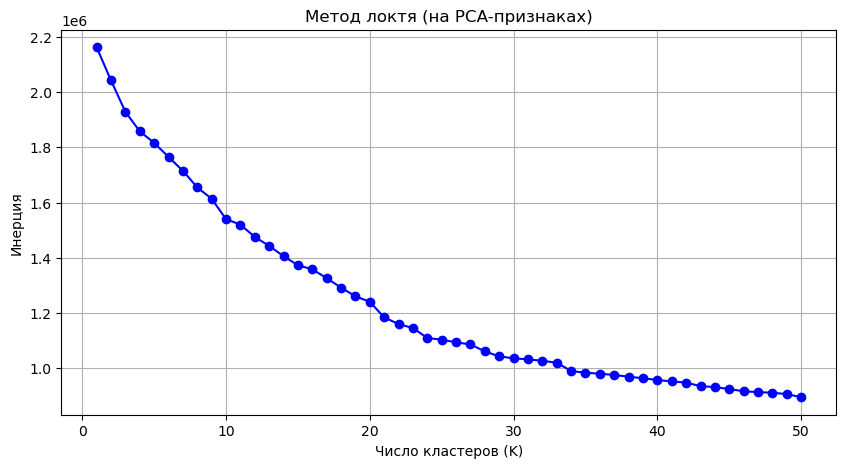

In [7]:
inertia = []
for k in range(1, 51):
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    km.fit(X_pca)
    inertia.append(km.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 51), inertia, marker='o', color='blue')
plt.xlabel('Число кластеров (K)')
plt.ylabel('Инерция')
plt.title('Метод локтя (на PCA-признаках)')
plt.grid(True)
plt.show()

In [8]:
final_kmeans = KMeans(n_clusters=2, random_state=42, n_init='auto')
cluster_labels = final_kmeans.fit_predict(X_pca)
df['cluster'] = cluster_labels

print("\nРаспределение объектов по кластерам:")
print(df['cluster'].value_counts().sort_index())


Распределение объектов по кластерам:
cluster
0    39621
1     1567
Name: count, dtype: int64


In [9]:
numeric_cols = ['age', 'duration', 'campaign', 'pdays', 'previous', 'euribor3m', 'emp.var.rate',
                'cons.price.idx', 'cons.conf.idx', 'nr.employed']
numeric_cols = [col for col in numeric_cols if col in df.columns]

cluster_profile_mean = df.groupby('cluster')[numeric_cols].mean()
cluster_profile_median = df.groupby('cluster')[numeric_cols].median()

print("\nСредние значения признаков по кластерам (на исходных данных):")
print(cluster_profile_mean.round(2))

print("\nМедианные значения признаков по кластерам (на исходных данных):")
print(cluster_profile_median.round(2))


Средние значения признаков по кластерам (на исходных данных):
           age  duration  campaign   pdays  previous  euribor3m  emp.var.rate  \
cluster                                                                         
0        39.95    255.73      2.60  999.00      0.11       3.73          0.17   
1        41.95    322.86      1.82   38.97      1.71       0.98         -2.10   

         cons.price.idx  cons.conf.idx  nr.employed  
cluster                                              
0                 93.58         -40.59      5172.53  
1                 93.35         -38.26      5028.03  

Медианные значения признаков по кластерам (на исходных данных):
          age  duration  campaign  pdays  previous  euribor3m  emp.var.rate  \
cluster                                                                       
0        38.0     177.0       2.0  999.0       0.0       4.86           1.1   
1        37.0     252.0       1.0    6.0       1.0       0.88          -1.8   

         cons.

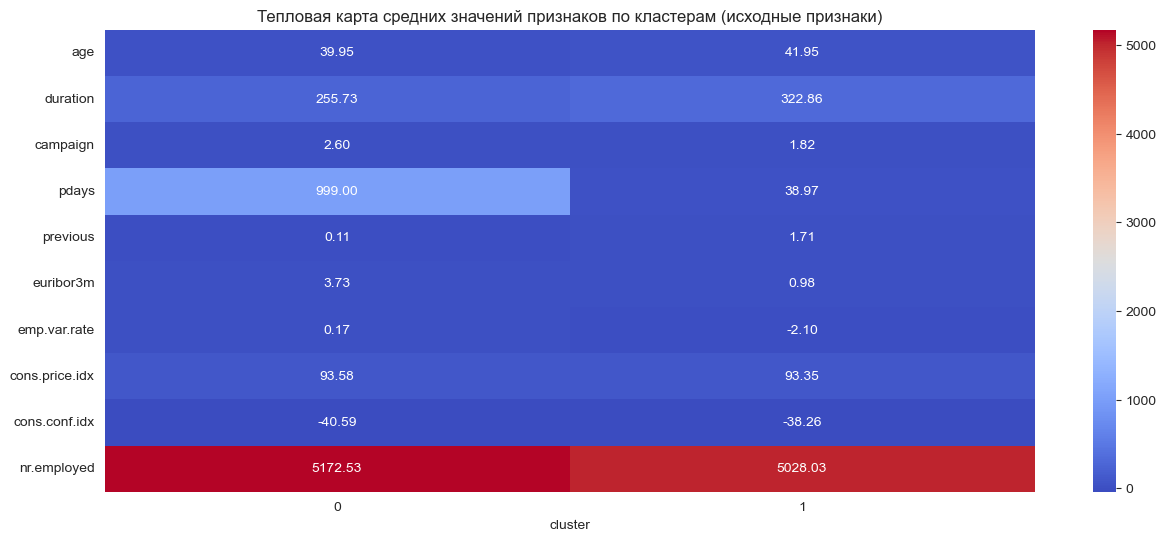

In [10]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

plt.figure(figsize=(15, 6))
sns.heatmap(cluster_profile_mean.T, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Тепловая карта средних значений признаков по кластерам (исходные признаки)')
plt.show()

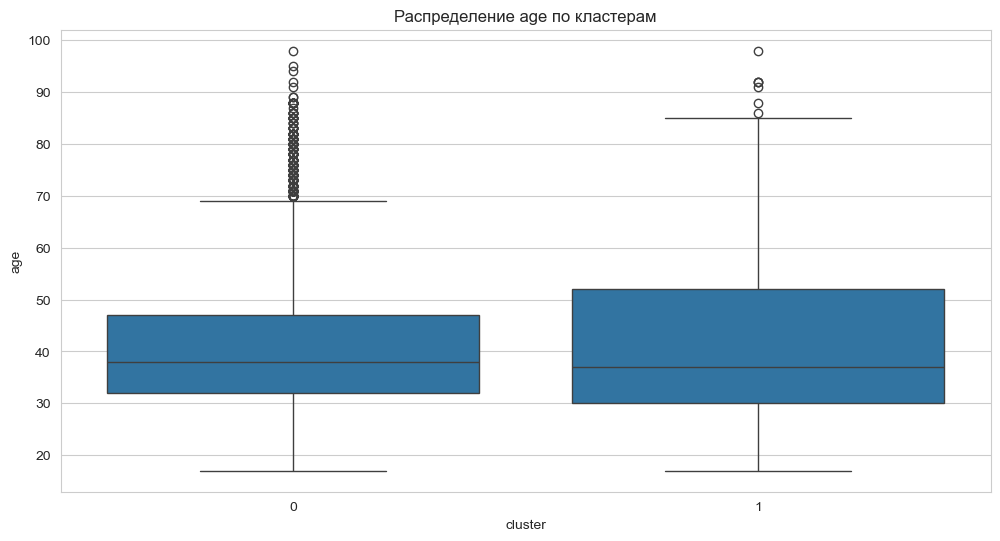

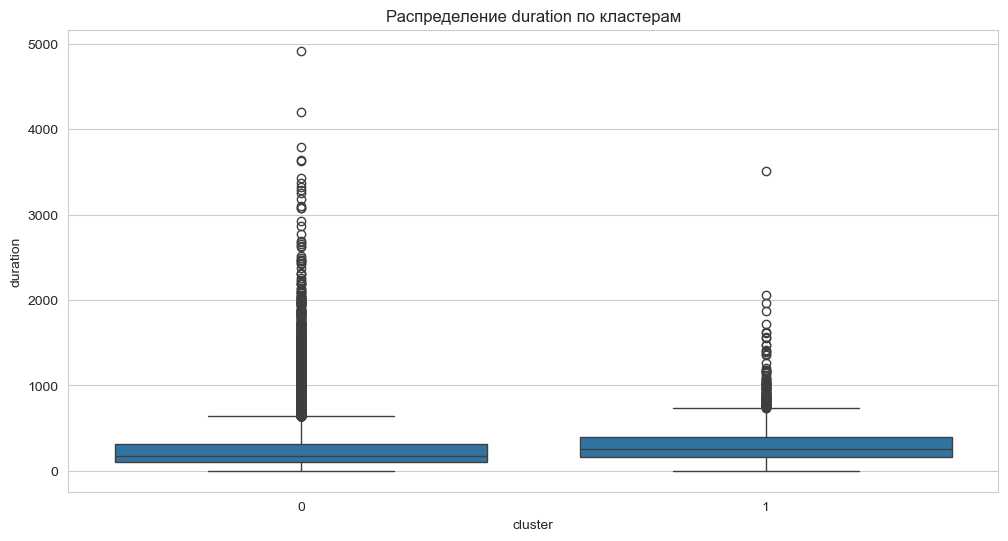

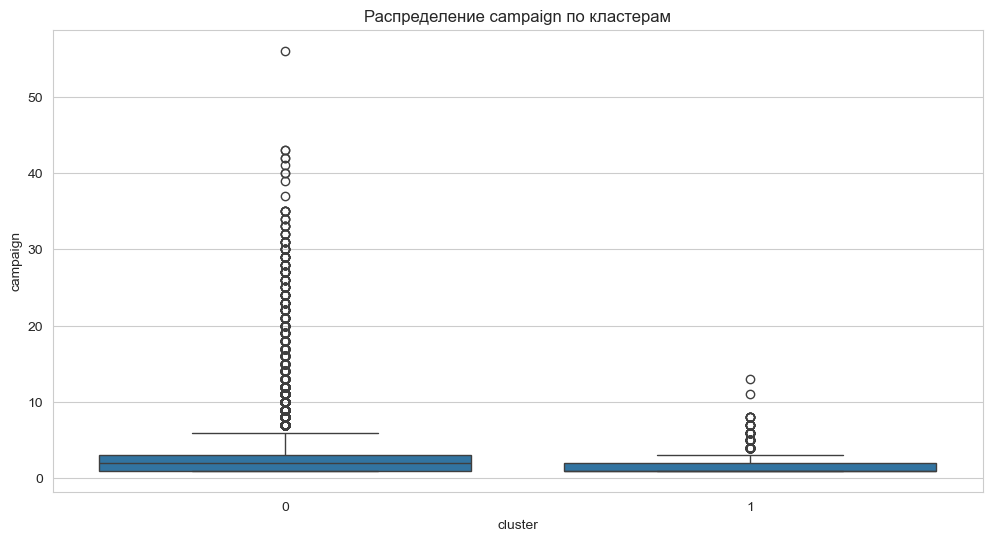

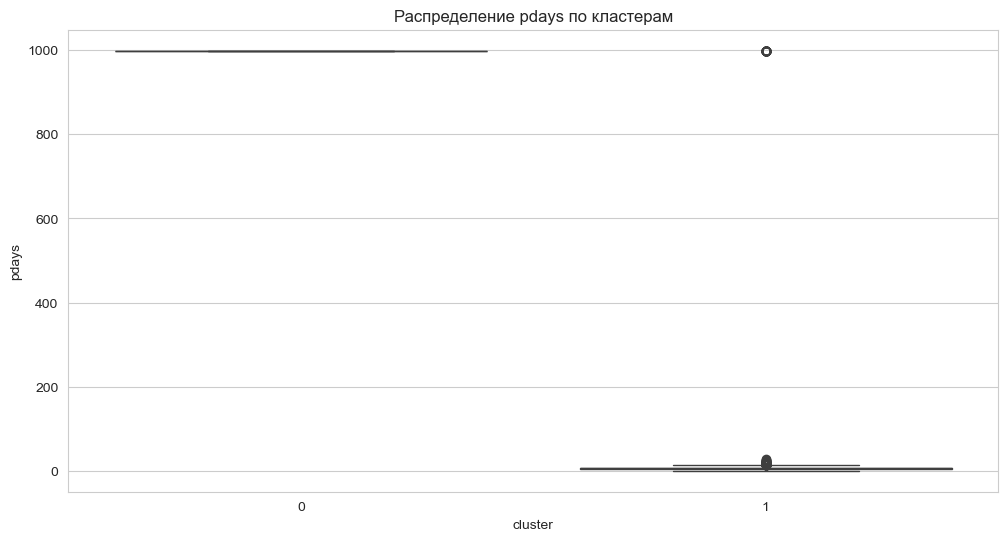

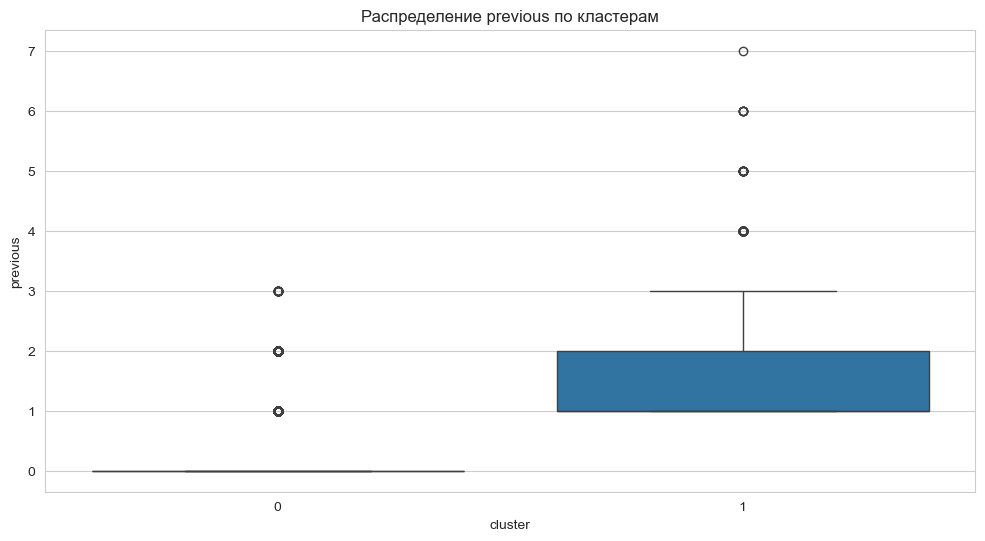

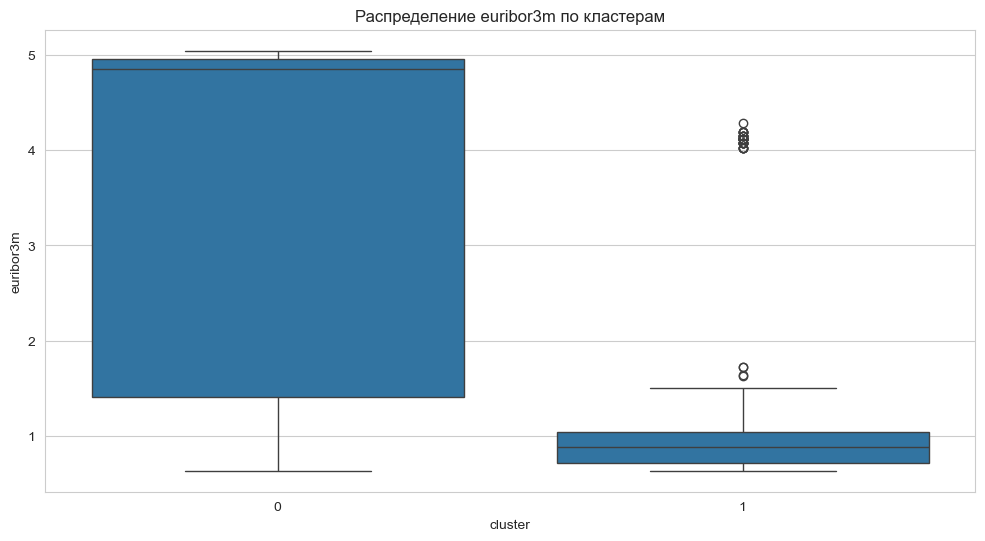

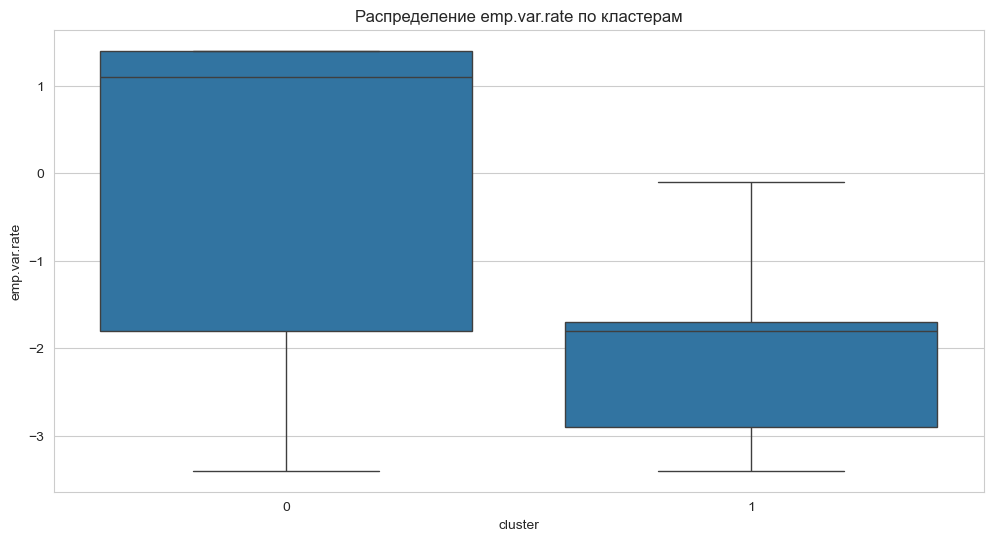

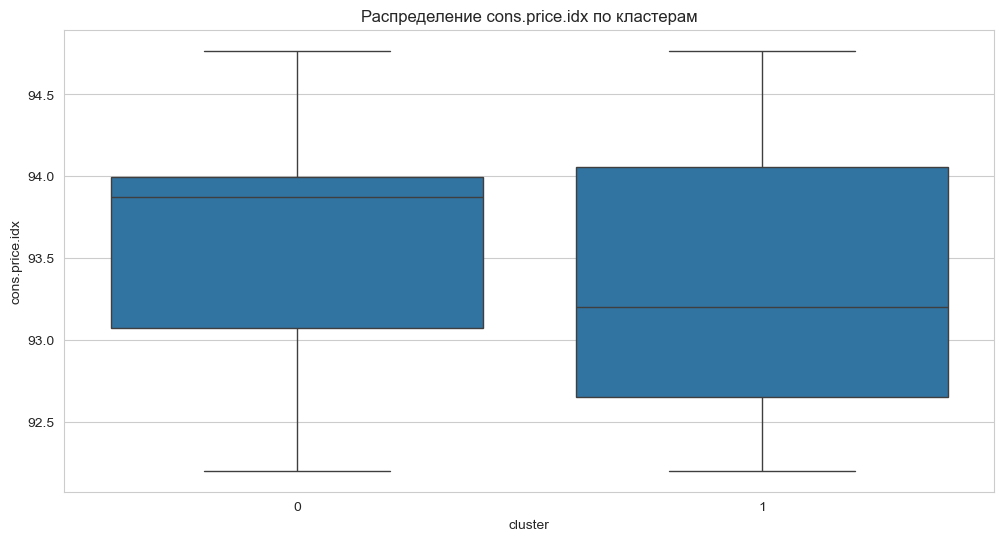

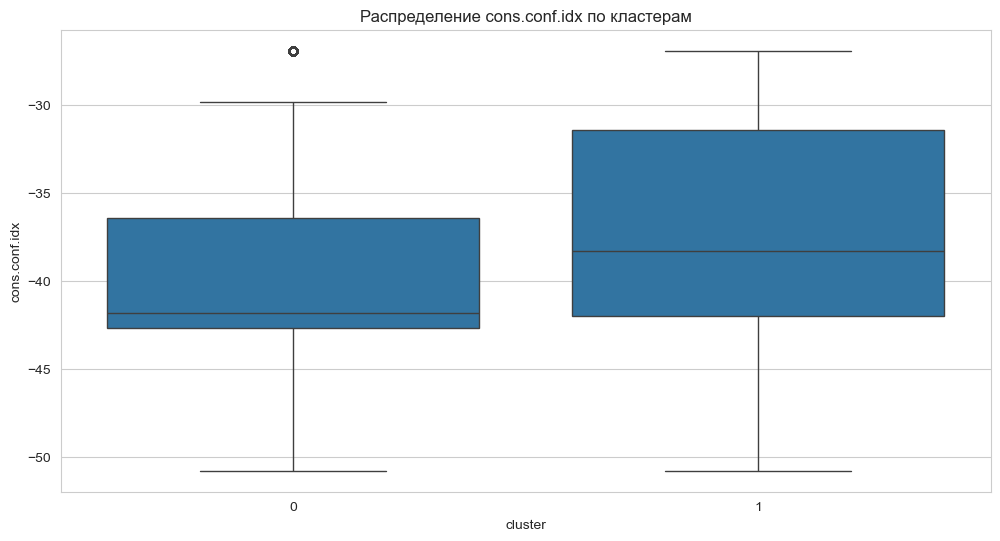

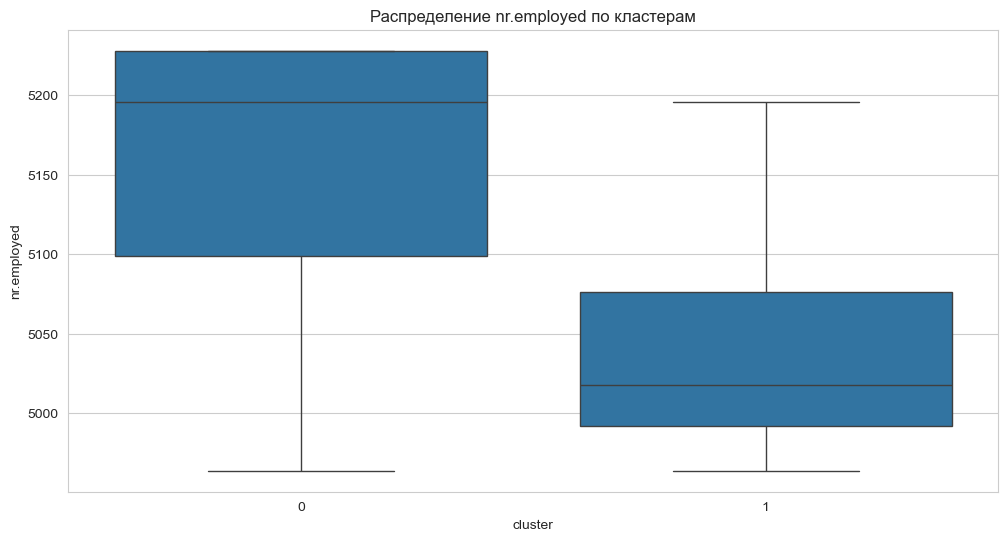

In [11]:
for col in numeric_cols:
    plt.figure()
    sns.boxplot(data=df, x='cluster', y=col)
    plt.title(f'Распределение {col} по кластерам')
    plt.show()

In [12]:
cat_cols = [col for col in df.columns if col not in numeric_cols + ['cluster']]
cluster_cat_profile = df.groupby('cluster')[cat_cols].mean()
print("\nСредние значения one-hot признаков по кластерам (на исходных данных):")
print(cluster_cat_profile.round(2))


Средние значения one-hot признаков по кластерам (на исходных данных):
         job_blue-collar  job_entrepreneur  job_housemaid  job_management  \
cluster                                                                     
0                   0.23              0.04           0.03            0.07   
1                   0.08              0.02           0.03            0.07   

         job_retired  job_self-employed  job_services  job_student  \
cluster                                                              
0               0.04               0.04          0.10         0.02   
1               0.12               0.02          0.05         0.10   

         job_technician  job_unemployed  ...  month_may  month_nov  month_oct  \
cluster                                  ...                                    
0                  0.16            0.02  ...       0.34       0.10       0.01   
1                  0.15            0.04  ...       0.16       0.12       0.11   

         month

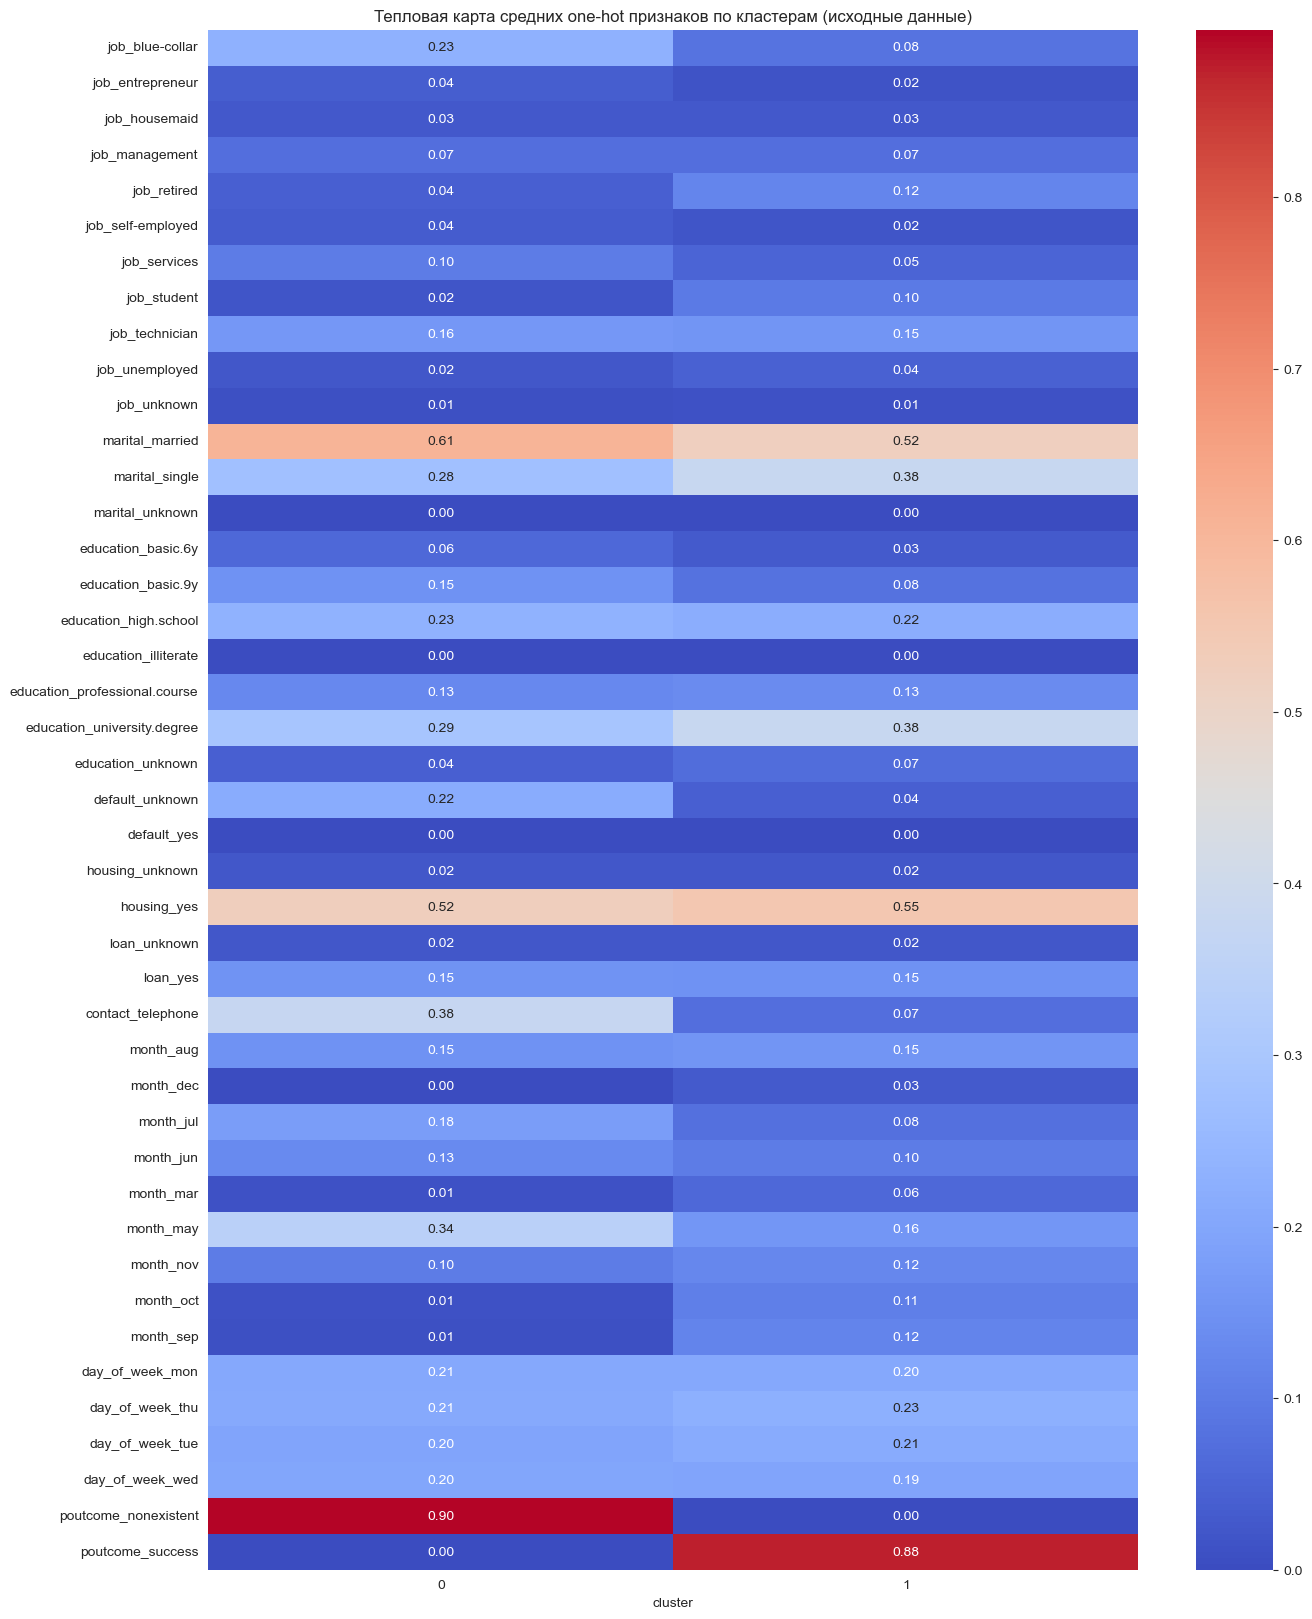

In [13]:
plt.figure(figsize=(15, 20))
sns.heatmap(cluster_cat_profile.T, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Тепловая карта средних one-hot признаков по кластерам (исходные данные)')
plt.show()

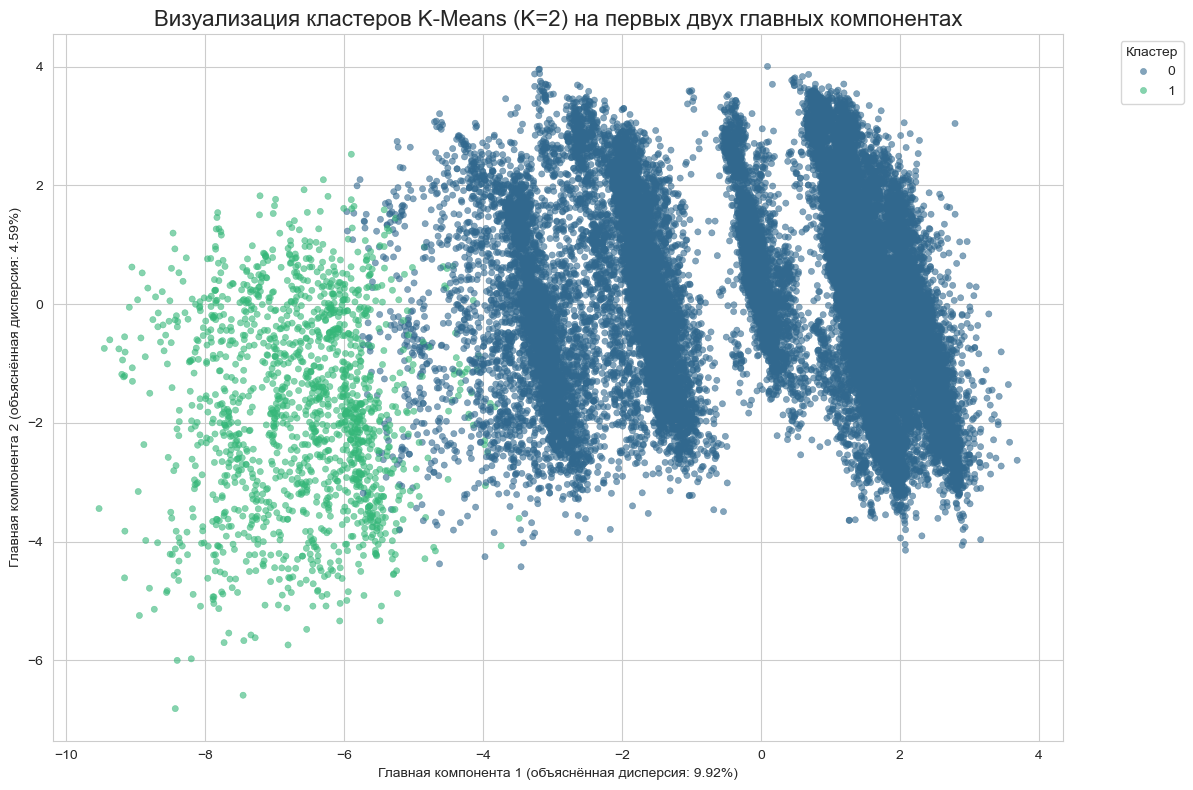

In [14]:
pca_df = pd.DataFrame({
    'PCA1': X_pca[:, 0],
    'PCA2': X_pca[:, 1],
    'Cluster': cluster_labels.astype(str)
})

plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(
    data=pca_df,
    x='PCA1', y='PCA2',
    hue='Cluster',
    palette='viridis',
    alpha=0.6,
    edgecolor=None,
    s=20
)
plt.title(f'Визуализация кластеров K-Means (K=2) на первых двух главных компонентах', fontsize=16)
plt.xlabel(f'Главная компонента 1 (объяснённая дисперсия: {pca_45.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'Главная компонента 2 (объяснённая дисперсия: {pca_45.explained_variance_ratio_[1]:.2%})')
plt.legend(title='Кластер', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

DBSCAN

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from kneed import KneeLocator

In [16]:
df = pd.read_csv(
    'bank+marketing/bank-additional/bank-additional/bank-additional-full.csv',
    sep=';', na_values=[''], quotechar='"'
)
df = df.drop(columns=['y'], errors='ignore')

categorical_cols = ['job', 'marital', 'education', 'default',
                    'housing', 'loan', 'contact', 'month',
                    'day_of_week', 'poutcome']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

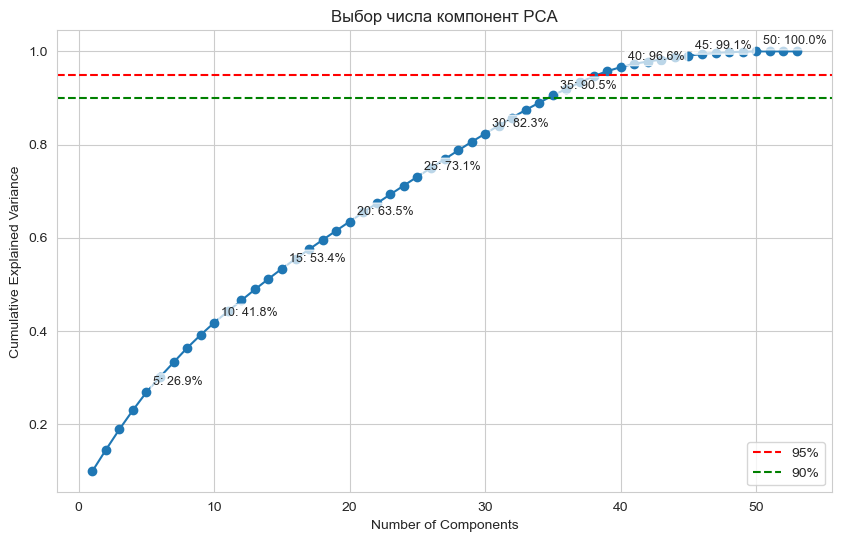

Для 95% дисперсии нужно 39 компонент
Для 90% дисперсии нужно 35 компонент


In [17]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

pca = PCA().fit(X_scaled)
cum_var = np.cumsum(pca.explained_variance_ratio_)
n_components = len(cum_var)
components = np.arange(1, n_components + 1)

plt.figure(figsize=(10,6))
plt.plot(range(1, len(cum_var)+1), cum_var, marker='o')
plt.axhline(y=0.95, color='r', linestyle='--', label='95%')
plt.axhline(y=0.90, color='g', linestyle='--', label='90%')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Выбор числа компонент PCA')
plt.legend()
plt.grid(True)

step = 5
indices = range(step - 1, n_components, step)
for i in indices:
    x = components[i]
    y = cum_var[i]
    label = f'{x}: {y:.1%}'
    plt.annotate(label,
                 xy=(x, y),
                 xytext=(5, 5),
                 textcoords='offset points',
                 fontsize=9,
                 bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

plt.show()

n_95 = np.argmax(cum_var >= 0.95) + 1
n_90 = np.argmax(cum_var >= 0.90) + 1
print(f"Для 95% дисперсии нужно {n_95} компонент")
print(f"Для 90% дисперсии нужно {n_90} компонент")

Автоматически найденный eps = 9.96


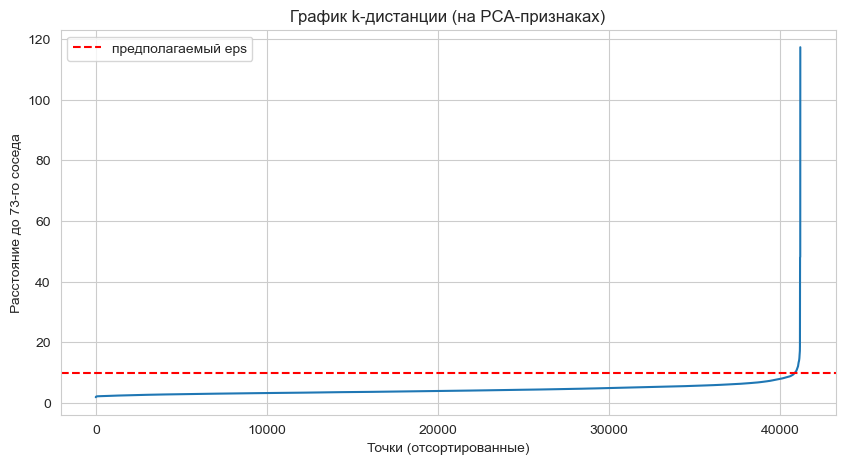

In [18]:
n_components = 39
pca = PCA(n_components=n_components, random_state=42)
X_pca = pca.fit_transform(X_scaled)

min_samples = 73

nn = NearestNeighbors(n_neighbors=min_samples)
nn.fit(X_pca)
distances, _ = nn.kneighbors(X_pca)
k_distances = distances[:, -1]
k_distances_sorted = np.sort(k_distances)

kneedle = KneeLocator(
    range(len(k_distances_sorted)), 
    k_distances_sorted, 
    curve='convex', 
    direction='increasing'
)
eps_auto = k_distances_sorted[kneedle.knee]
print(f"Автоматически найденный eps = {eps_auto:.2f}")

plt.figure(figsize=(10, 5))
plt.plot(k_distances_sorted)
plt.axhline(y=eps_auto, color='r', linestyle='--', label='предполагаемый eps')
plt.xlabel('Точки (отсортированные)')
plt.ylabel(f'Расстояние до {min_samples}-го соседа')
plt.title('График k-дистанции (на PCA-признаках)')
plt.legend()
plt.grid(True)
plt.show()

In [19]:
import hdbscan

min_cluster_size = 59

clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, 
                            metric='euclidean', 
                            cluster_selection_method='eom')
labels = clusterer.fit_predict(X_pca)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)
print(f"Кластеров: {n_clusters}, шума: {n_noise} ({n_noise/len(labels):.1%})")

Кластеров: 15, шума: 5497 (13.3%)


In [20]:
unique_labels = set(labels)
n_clusters = len(unique_labels) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)
print(f"\nИтог (HDBSCAN): кластеров = {n_clusters}, шумовых точек = {n_noise} "
      f"({100*n_noise/len(labels):.1f}%)")


Итог (HDBSCAN): кластеров = 15, шумовых точек = 5497 (13.3%)


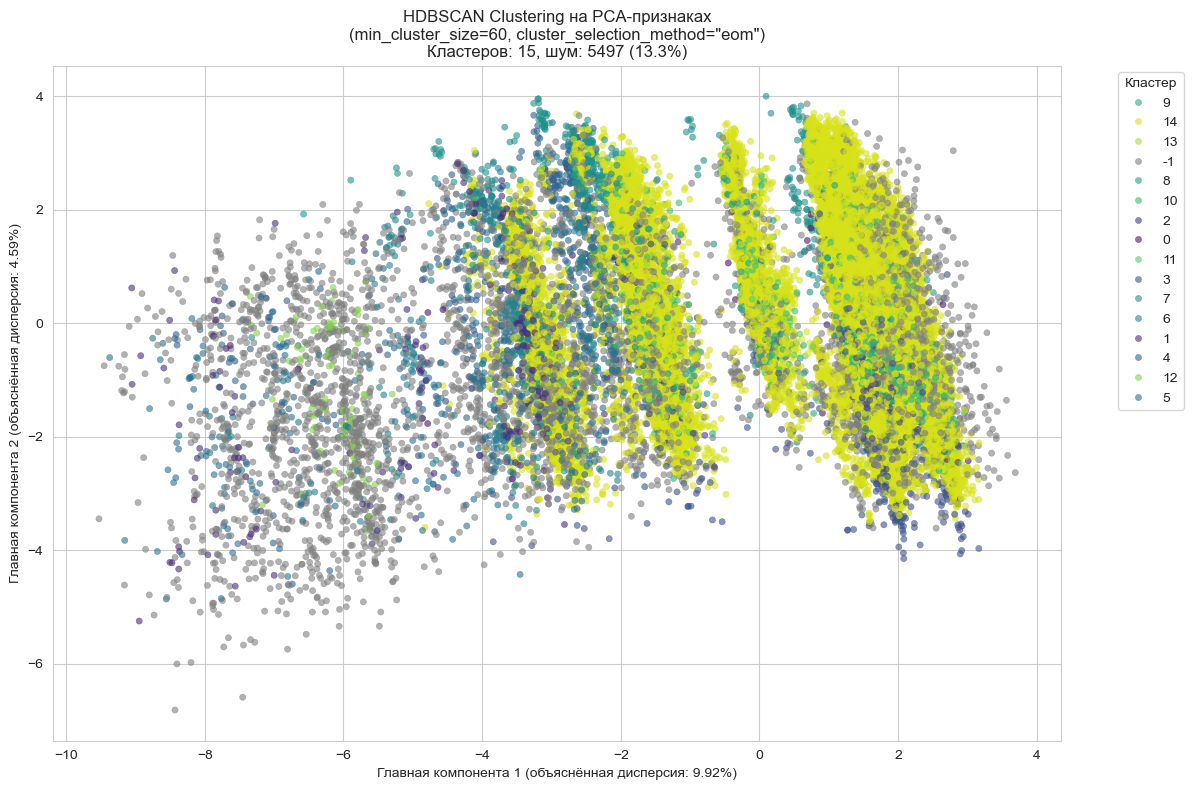

In [21]:
pca_df = pd.DataFrame({
    'PCA1': X_pca[:, 0],
    'PCA2': X_pca[:, 1],
    'Cluster': labels.astype(str)
})

# Палитра: цвета для кластеров, серый для шума (-1)
palette = {str(i): color for i, color in enumerate(sns.color_palette("viridis", n_clusters))}
palette['-1'] = (0.5, 0.5, 0.5)

plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(
    data=pca_df,
    x='PCA1', y='PCA2',
    hue='Cluster',
    palette=palette,
    alpha=0.6,
    edgecolor=None,
    s=20
)
plt.title(f'HDBSCAN Clustering на PCA-признаках\n'
          f'(min_cluster_size=60, cluster_selection_method="eom")\n'
          f'Кластеров: {n_clusters}, шум: {n_noise} ({100*n_noise/len(labels):.1f}%)')
plt.xlabel(f'Главная компонента 1 (объяснённая дисперсия: {pca.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'Главная компонента 2 (объяснённая дисперсия: {pca.explained_variance_ratio_[1]:.2%})')
plt.legend(title='Кластер', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [22]:
df['cluster_hdbscan'] = labels

df_no_noise = df[df['cluster_hdbscan'] != -1].copy()

if len(df_no_noise) > 0:
    numeric_cols = ['age', 'duration', 'campaign', 'pdays', 'previous',
                    'euribor3m', 'emp.var.rate', 'cons.price.idx',
                    'cons.conf.idx', 'nr.employed']
    numeric_cols = [col for col in numeric_cols if col in df_no_noise.columns]

    cluster_profile_mean = df_no_noise.groupby('cluster_hdbscan')[numeric_cols].mean()
    cluster_profile_median = df_no_noise.groupby('cluster_hdbscan')[numeric_cols].median()

    print("\nСредние значения признаков по кластерам (на исходных данных, без шума):")
    print(cluster_profile_mean.round(2))

    print("\nМедианные значения признаков по кластерам (на исходных данных, без шума):")
    print(cluster_profile_median.round(2))


Средние значения признаков по кластерам (на исходных данных, без шума):
                   age  duration  campaign   pdays  previous  euribor3m  \
cluster_hdbscan                                                           
0                40.28    312.73      3.19  937.10      0.28       3.31   
1                47.31    339.39      2.17  752.16      0.61       0.87   
2                45.50    235.15      2.69  982.31      0.06       4.16   
3                39.94    237.61      2.55  996.82      0.11       3.87   
4                40.69    229.82      2.19  889.39      0.39       1.20   
5                44.01    270.66      1.78  780.62      0.70       0.83   
6                45.72    259.01      1.46  974.71      0.28       1.22   
7                26.07    257.77      2.11  995.41      0.20       2.16   
8                39.43    227.03      2.42  999.00      0.06       3.88   
9                44.32    232.07      2.46  999.00      0.02       4.46   
10               39.99    2

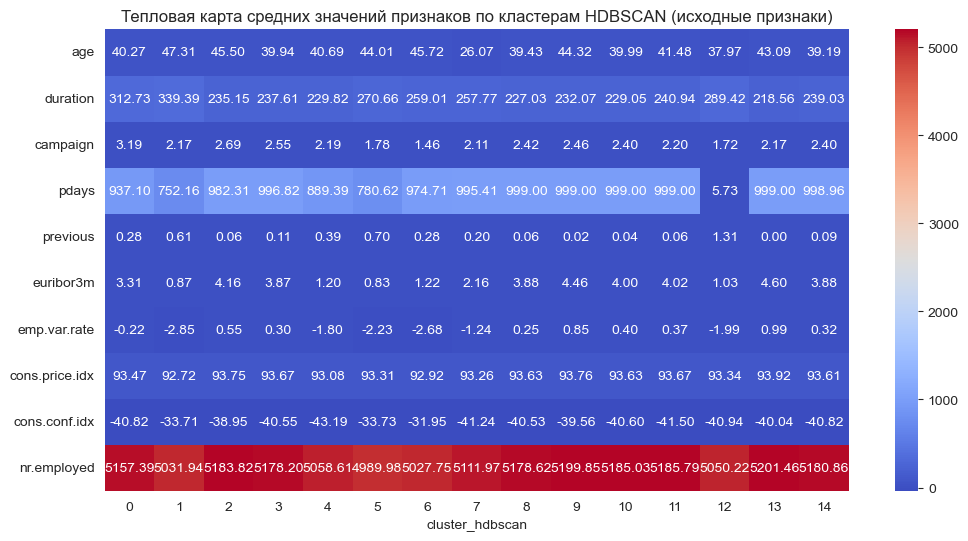

In [23]:
plt.figure(figsize=(12, 6))
sns.heatmap(cluster_profile_mean.T, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Тепловая карта средних значений признаков по кластерам HDBSCAN (исходные признаки)')
plt.show()

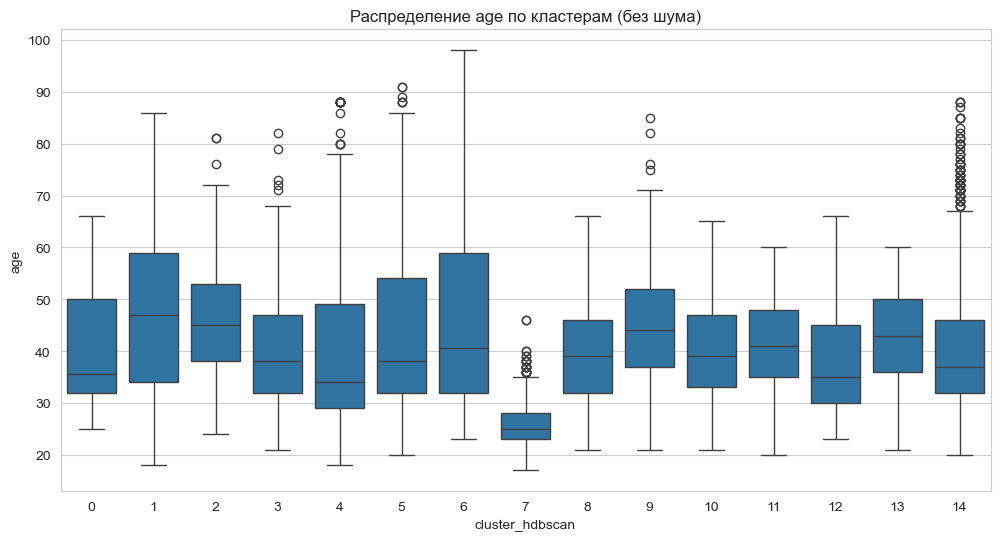

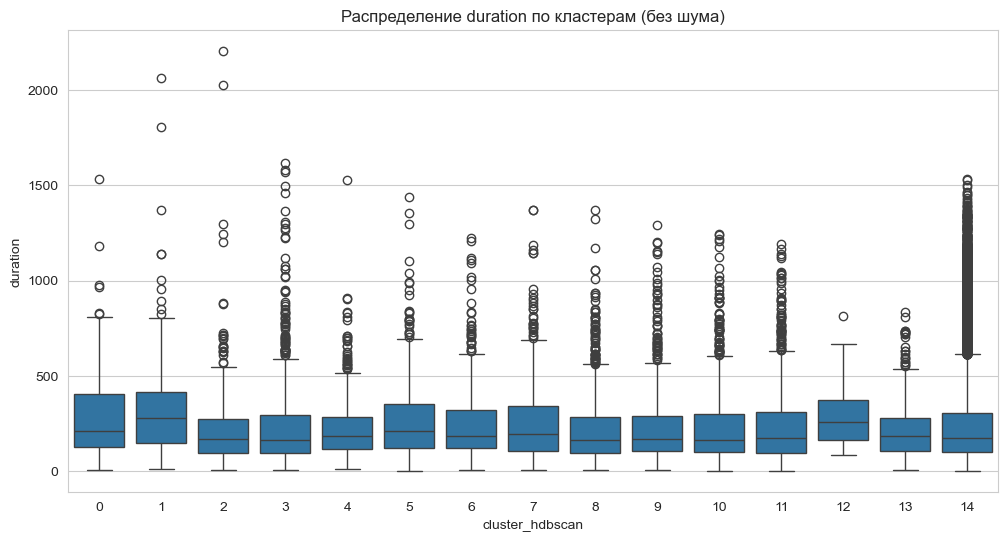

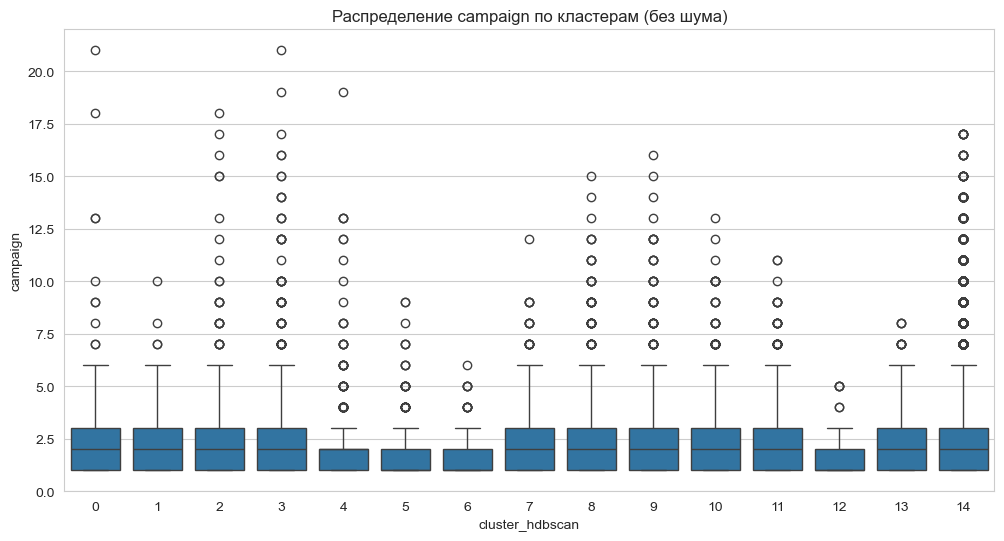

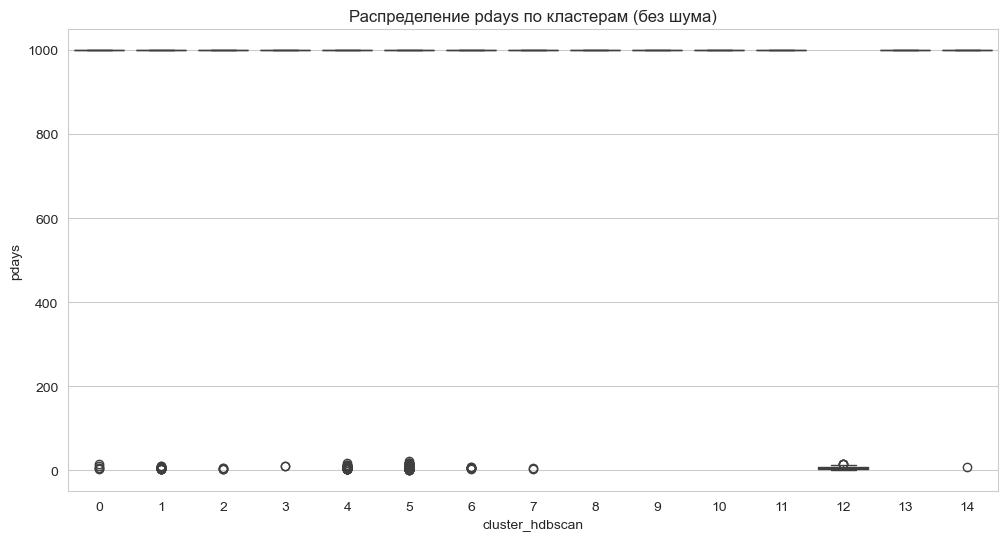

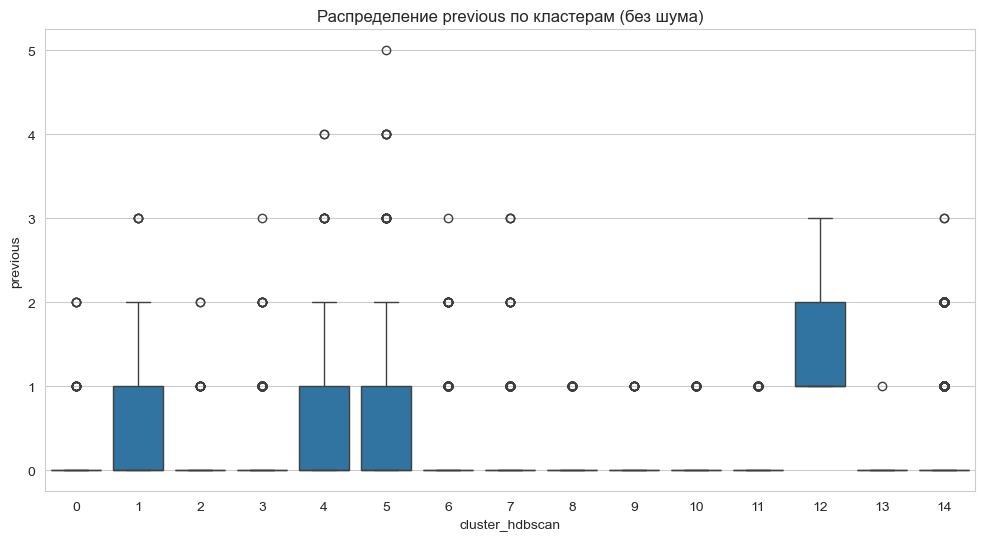

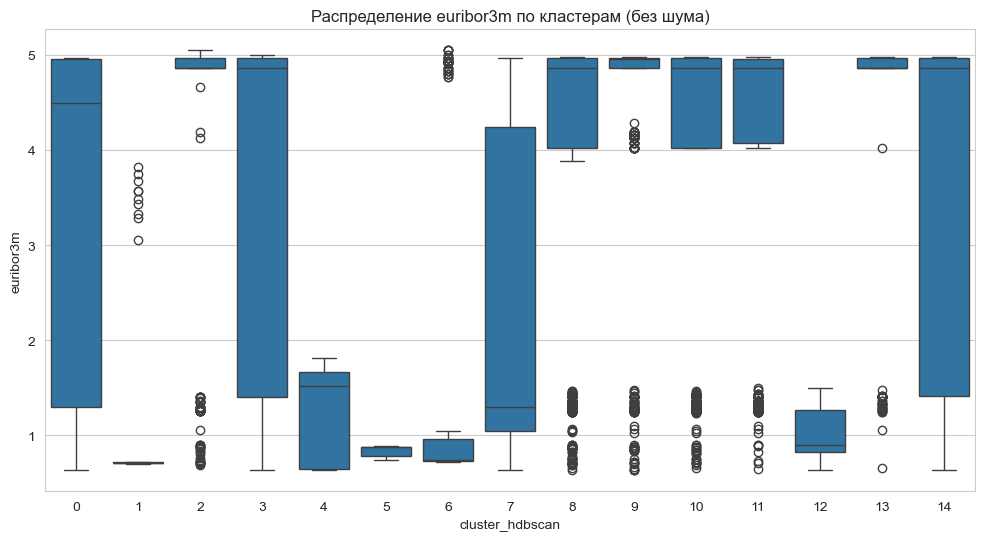

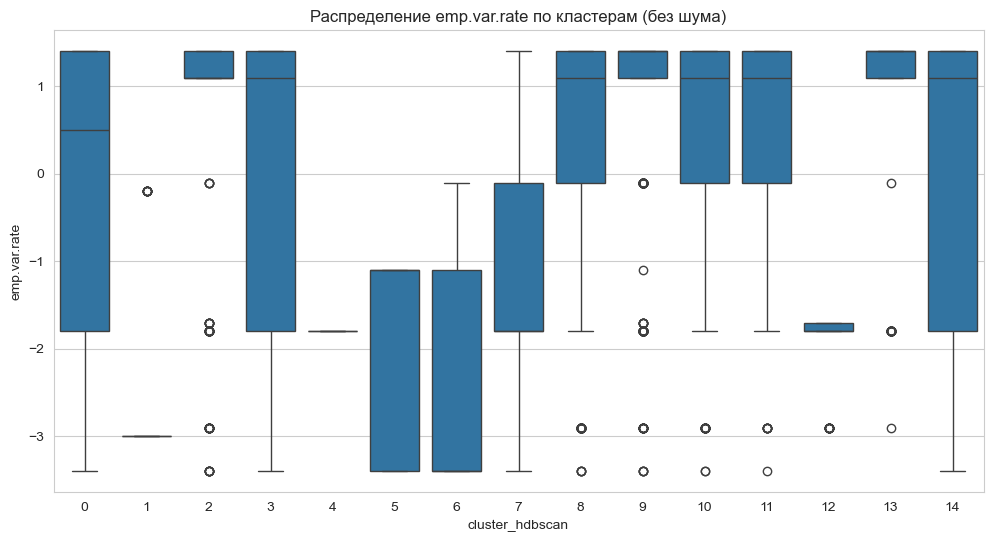

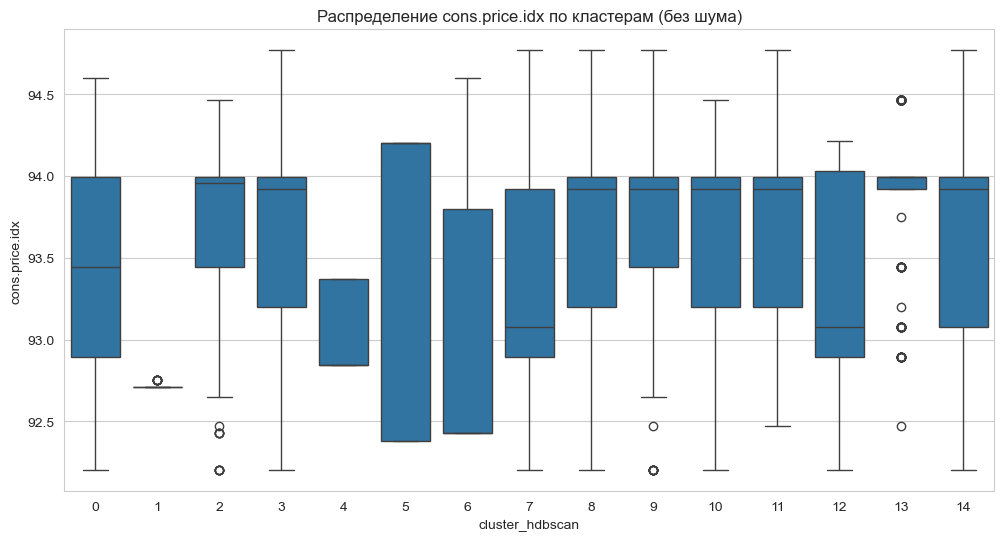

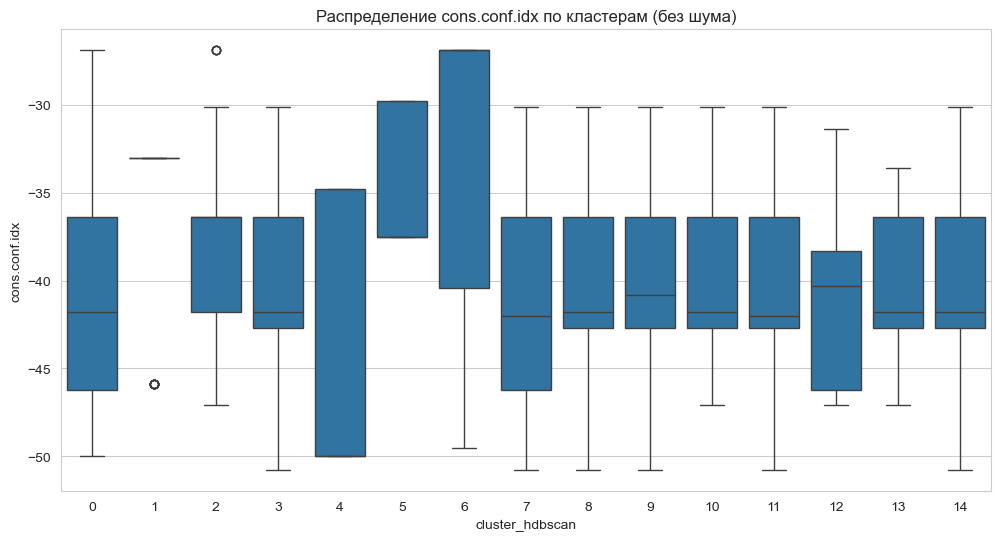

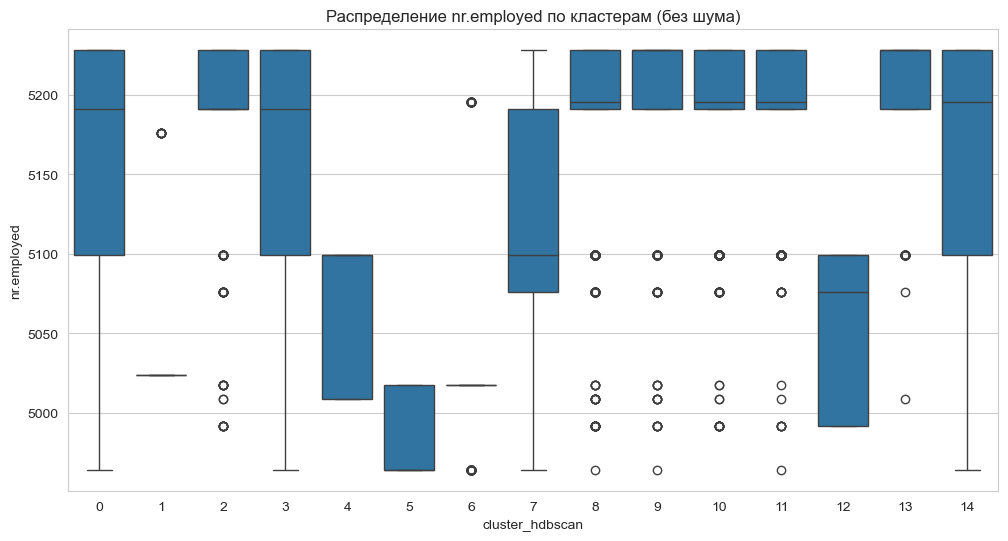

In [24]:
for col in numeric_cols:
    plt.figure()
    sns.boxplot(data=df_no_noise, x='cluster_hdbscan', y=col)
    plt.title(f'Распределение {col} по кластерам (без шума)')
    plt.show()

In [25]:
cat_cols = [col for col in df.columns if col not in numeric_cols + ['cluster_hdbscan']]
cluster_cat_profile = df_no_noise.groupby('cluster_hdbscan')[cat_cols].mean()
print("\nСредние значения one-hot признаков по кластерам (на исходных данных, без шума):")
print(cluster_cat_profile.round(2))


Средние значения one-hot признаков по кластерам (на исходных данных, без шума):
                 job_blue-collar  job_entrepreneur  job_housemaid  \
cluster_hdbscan                                                     
0                           0.18              0.04           0.04   
1                           0.07              0.01           0.06   
2                           0.00              0.00           0.00   
3                           0.26              0.04           0.03   
4                           0.10              0.00           0.01   
5                           0.04              0.01           0.00   
6                           0.07              0.00           0.00   
7                           0.00              0.00           0.00   
8                           0.00              0.00           0.00   
9                           0.00              0.00           1.00   
10                          0.00              0.00           0.00   
11                    

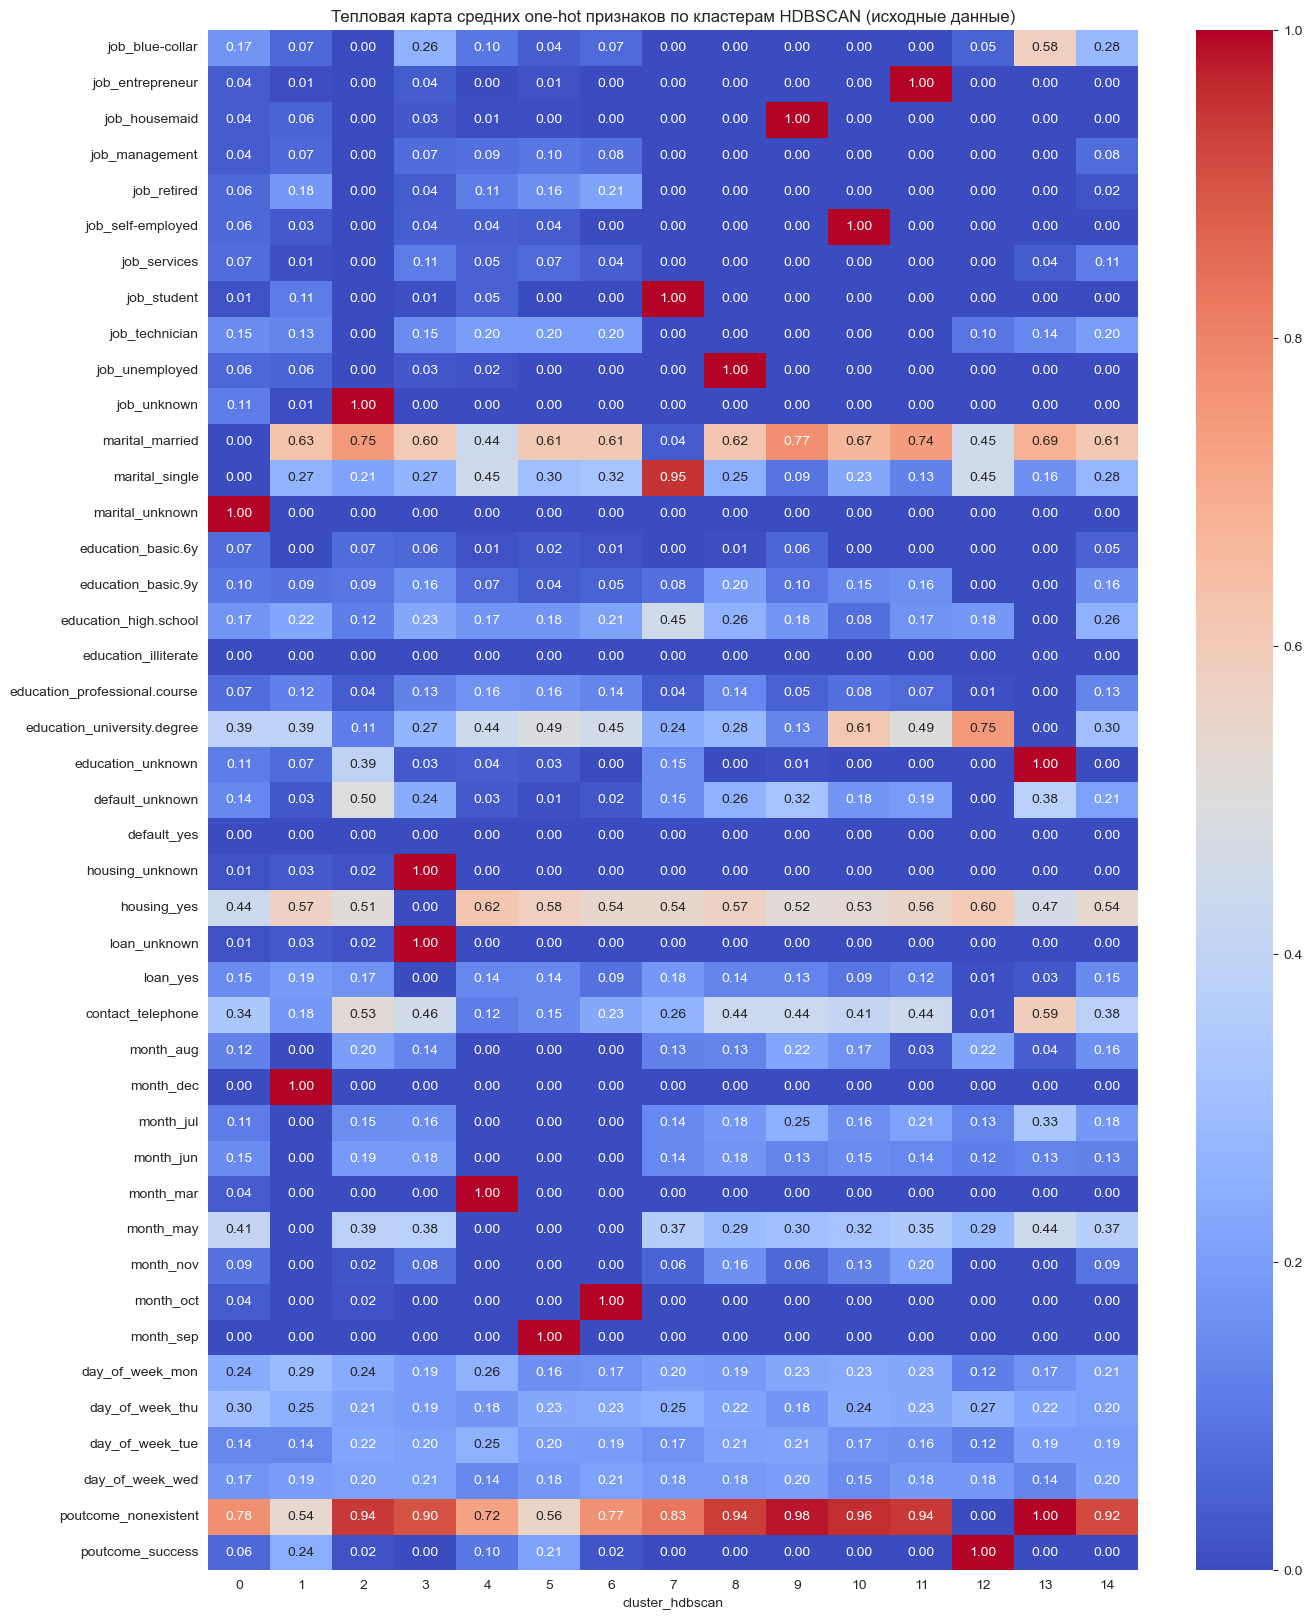

In [26]:
plt.figure(figsize=(15, 20))
sns.heatmap(cluster_cat_profile.T, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Тепловая карта средних one-hot признаков по кластерам HDBSCAN (исходные данные)')
plt.show()

AgglomerativeClustering

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

In [28]:
df = pd.read_csv(
    'bank+marketing/bank-additional/bank-additional/bank-additional-full.csv',
    sep=';', na_values=[''], quotechar='"'
)
df = df.drop(columns=['y'], errors='ignore')

categorical_cols = ['job', 'marital', 'education', 'default',
                    'housing', 'loan', 'contact', 'month',
                    'day_of_week', 'poutcome']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [29]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

n_components = 29
pca = PCA(n_components=n_components, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Размерность после PCA: {X_pca.shape[1]}")

Размерность после PCA: 29


Оптимальное число кластеров (по наибольшему разрыву): 2


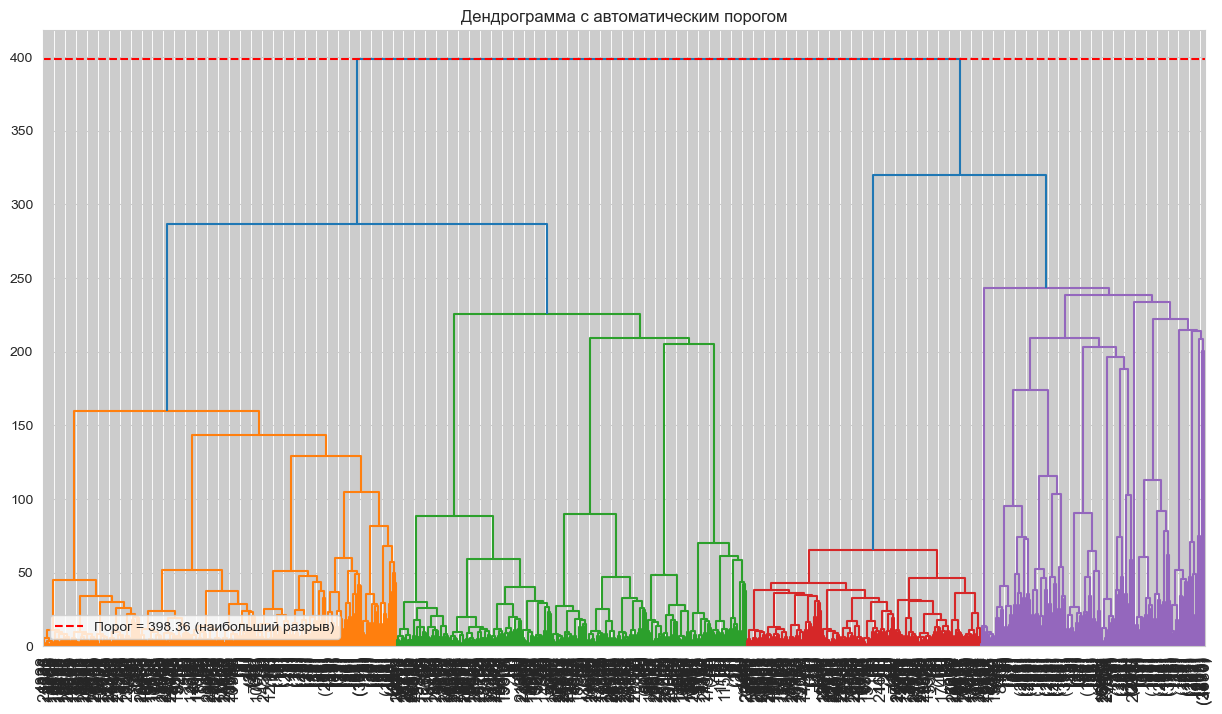

In [30]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import numpy as np
import matplotlib.pyplot as plt

sample_size = 25000
indices = np.random.choice(X_pca.shape[0], sample_size, replace=False)
X_sample = X_pca[indices]

linkage_matrix = linkage(X_sample, method='ward', metric='euclidean')
distances = linkage_matrix[:, 2]
diffs = np.diff(distances)
max_diff_idx = np.argmax(diffs) + 1
optimal_n_clusters = sample_size - max_diff_idx

print(f"Оптимальное число кластеров (по наибольшему разрыву): {optimal_n_clusters}")

plt.figure(figsize=(15, 8))
dendrogram(linkage_matrix, truncate_mode='level', p=10, 
           leaf_rotation=90., leaf_font_size=12.)
plt.axhline(y=distances[max_diff_idx], color='r', linestyle='--', 
            label=f'Порог = {distances[max_diff_idx]:.2f} (наибольший разрыв)')
plt.legend()
plt.title('Дендрограмма с автоматическим порогом')
plt.show()

In [31]:
from sklearn.neighbors import KNeighborsClassifier

n_clusters = 2
sample_size = 25000
random_state = 42

n_total = X_pca.shape[0]
indices = np.random.RandomState(random_state).choice(n_total, sample_size, replace=False)
X_sample = X_pca[indices]

clusterer = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
labels_sample = clusterer.fit_predict(X_sample)

knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_sample, labels_sample)
labels = knn.predict(X_pca)

unique_labels = set(labels)
n_clusters_found = len(unique_labels)
n_noise = 0
print(f"\nИтог (AgglomerativeClustering + KNN): кластеров = {n_clusters_found}, "
      f"шумовых точек = {n_noise}")


Итог (AgglomerativeClustering + KNN): кластеров = 2, шумовых точек = 0


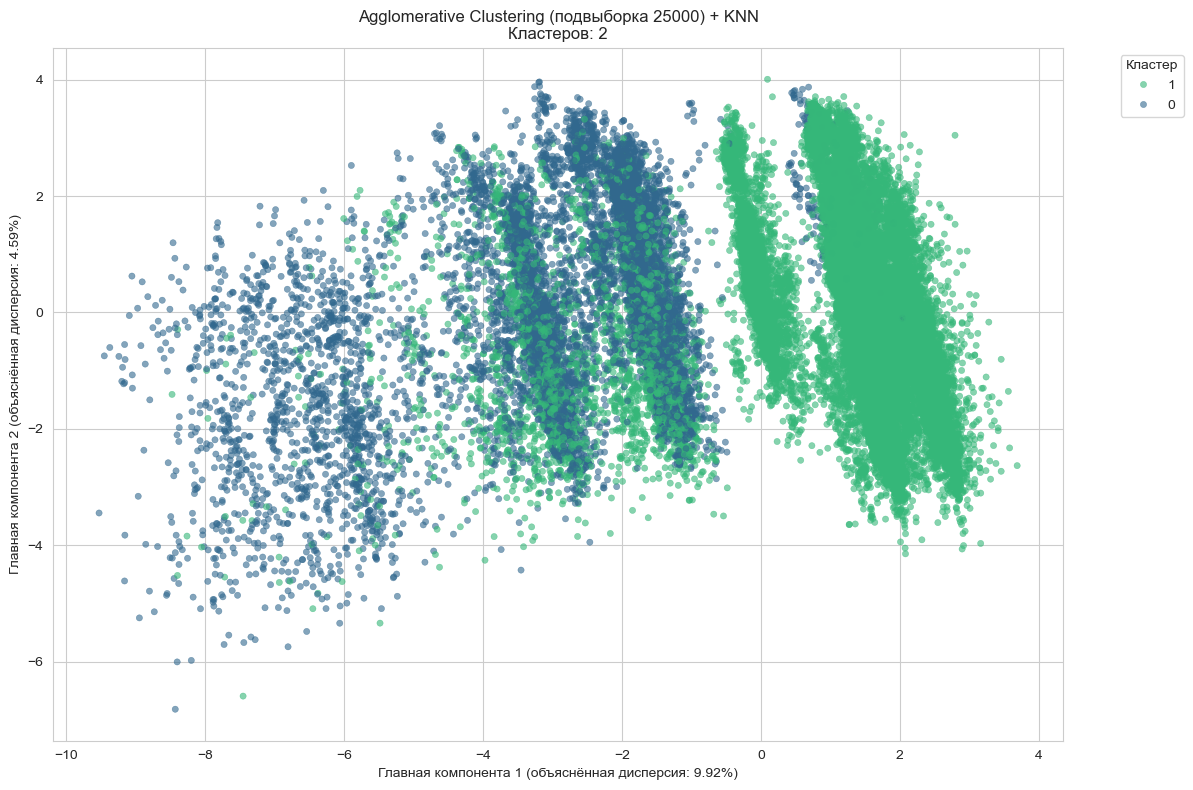

In [32]:
pca_df = pd.DataFrame({
    'PCA1': X_pca[:, 0],
    'PCA2': X_pca[:, 1],
    'Cluster': labels.astype(str)
})

palette = {str(i): color for i, color in enumerate(sns.color_palette("viridis", n_clusters_found))}

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=pca_df,
    x='PCA1', y='PCA2',
    hue='Cluster',
    palette=palette,
    alpha=0.6,
    edgecolor=None,
    s=20
)
plt.title(f'Agglomerative Clustering (подвыборка {sample_size}) + KNN\n'
          f'Кластеров: {n_clusters_found}')
plt.xlabel(f'Главная компонента 1 (объяснённая дисперсия: {pca.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'Главная компонента 2 (объяснённая дисперсия: {pca.explained_variance_ratio_[1]:.2%})')
plt.legend(title='Кластер', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [33]:
df['cluster_agg'] = labels

df_no_noise = df.copy()

numeric_cols = ['age', 'duration', 'campaign', 'pdays', 'previous',
                'euribor3m', 'emp.var.rate', 'cons.price.idx',
                'cons.conf.idx', 'nr.employed']
numeric_cols = [col for col in numeric_cols if col in df_no_noise.columns]

cluster_profile_mean = df_no_noise.groupby('cluster_agg')[numeric_cols].mean()
cluster_profile_median = df_no_noise.groupby('cluster_agg')[numeric_cols].median()

print("\nСредние значения признаков по кластерам:")
print(cluster_profile_mean.round(2))

print("\nМедианные значения признаков по кластерам:")
print(cluster_profile_median.round(2))


Средние значения признаков по кластерам:
               age  duration  campaign   pdays  previous  euribor3m  \
cluster_agg                                                           
0            37.92    265.48      2.11  860.65      0.50       1.25   
1            40.74    255.84      2.72  997.06      0.06       4.43   

             emp.var.rate  cons.price.idx  cons.conf.idx  nr.employed  
cluster_agg                                                            
0                   -1.95           93.05         -42.91      5076.18  
1                    0.77           93.76         -39.68      5197.90  

Медианные значения признаков по кластерам:
              age  duration  campaign  pdays  previous  euribor3m  \
cluster_agg                                                         
0            35.0     201.0       2.0  999.0       0.0       1.28   
1            39.0     172.0       2.0  999.0       0.0       4.86   

             emp.var.rate  cons.price.idx  cons.conf.idx  nr.emp

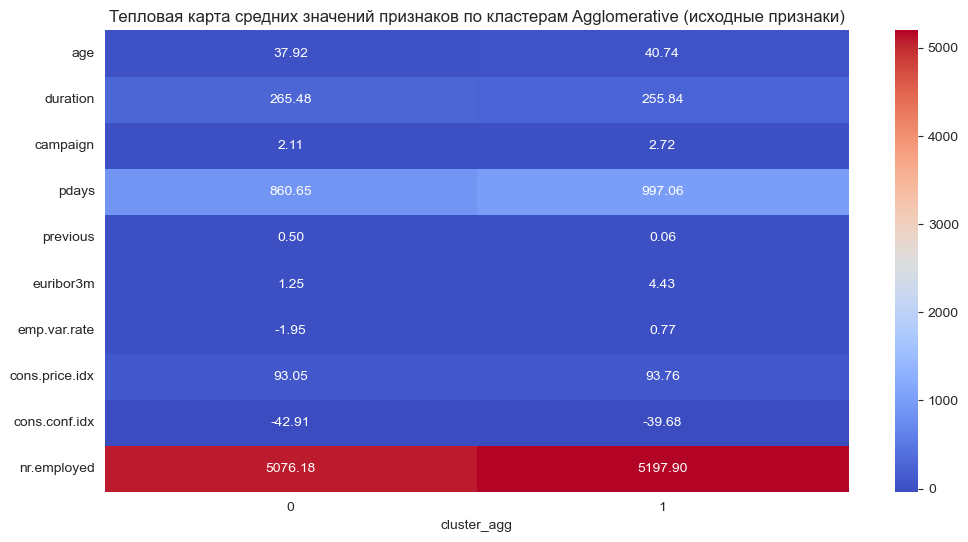

In [34]:
plt.figure(figsize=(12, 6))
sns.heatmap(cluster_profile_mean.T, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Тепловая карта средних значений признаков по кластерам Agglomerative (исходные признаки)')
plt.show()

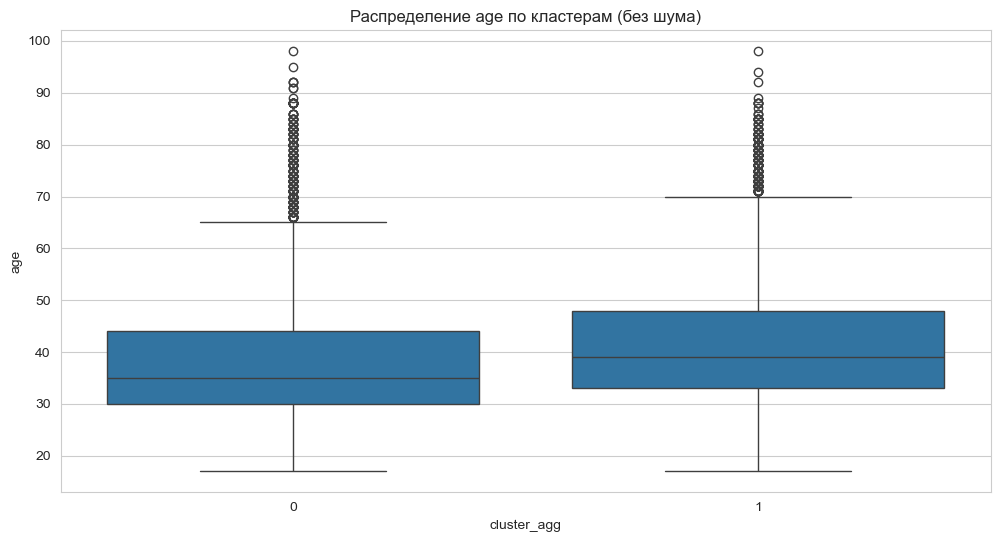

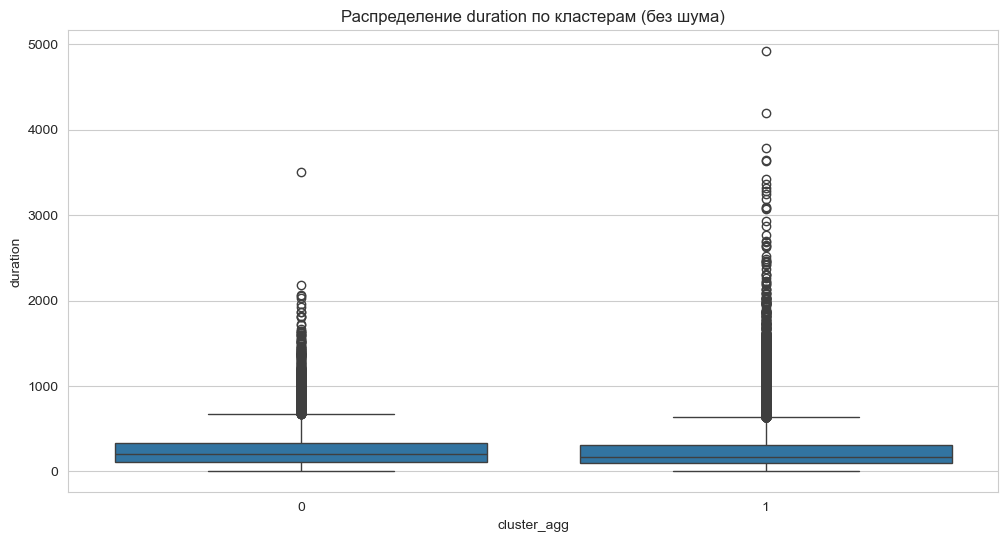

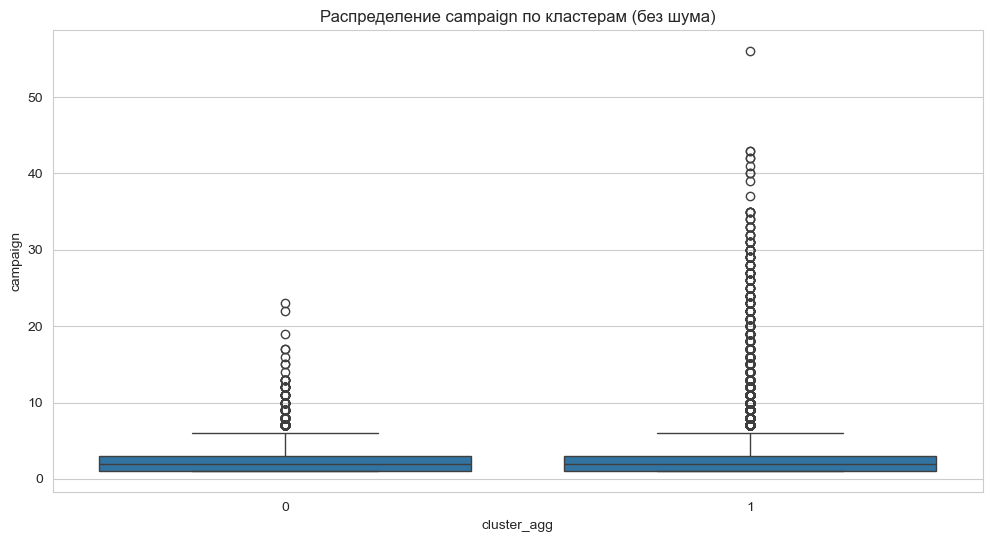

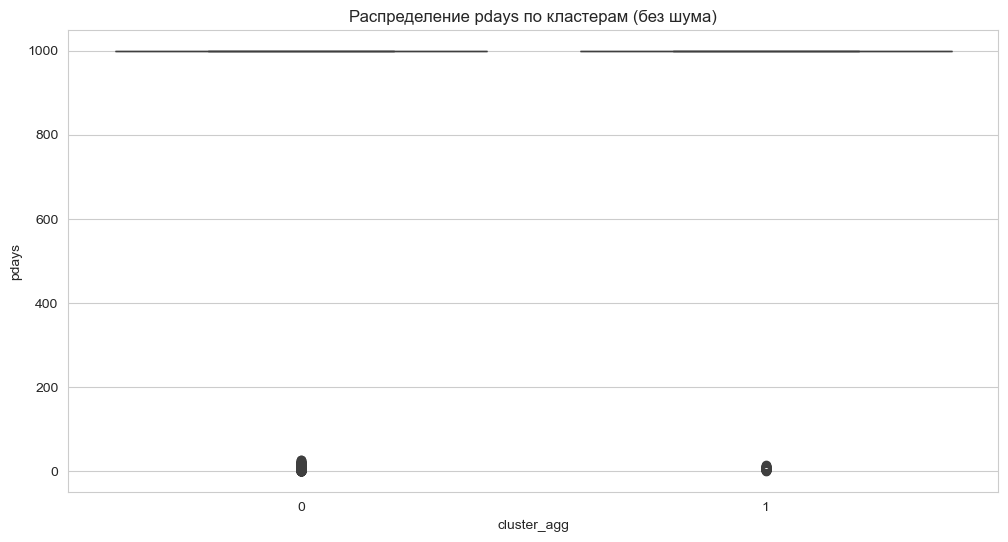

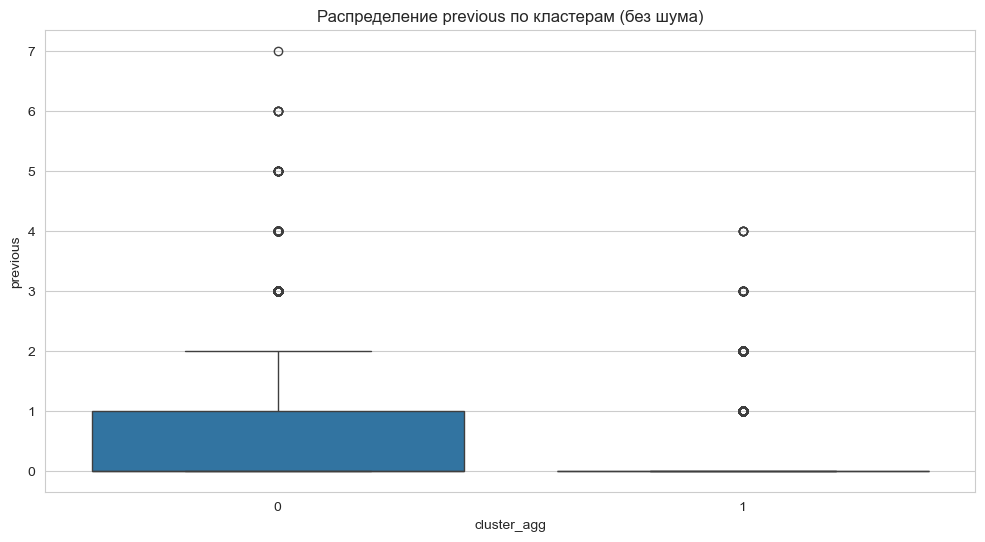

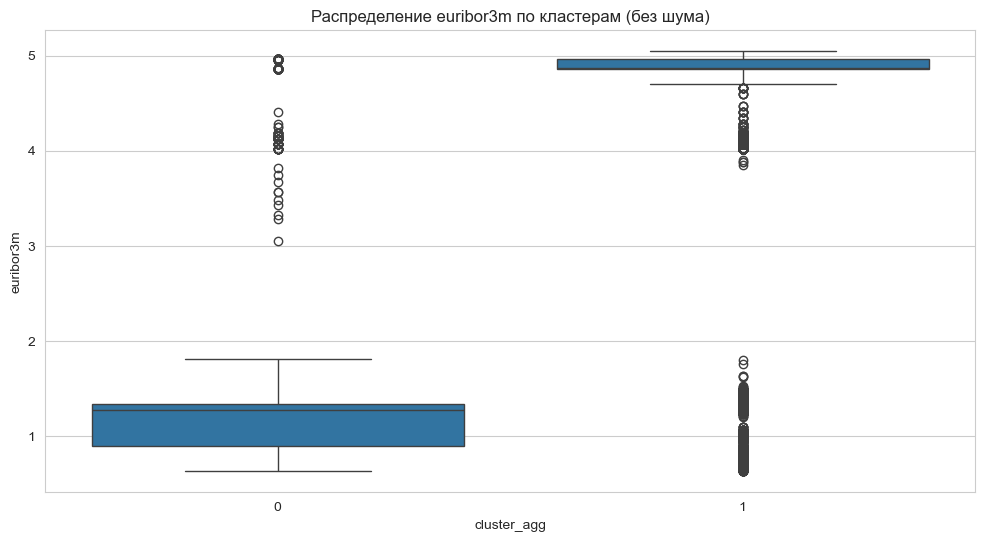

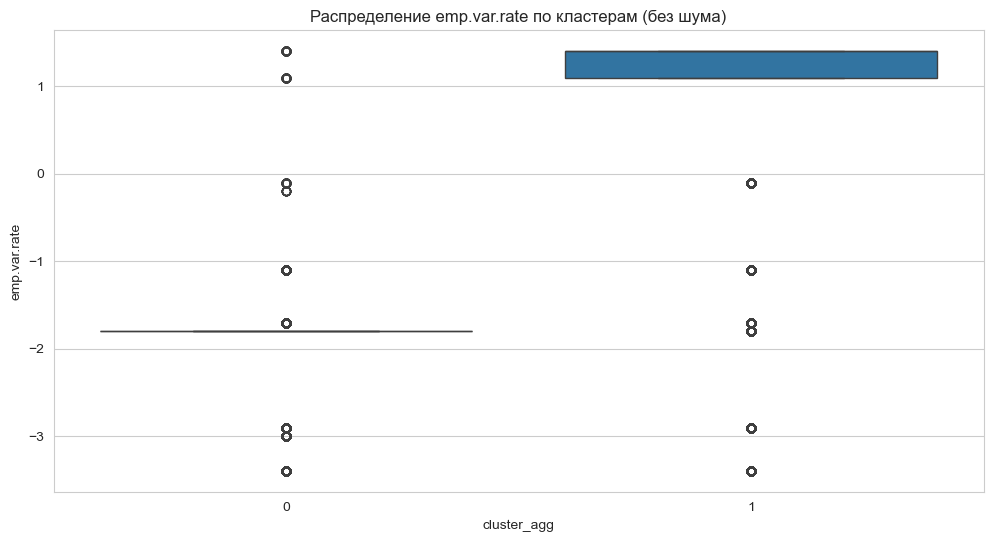

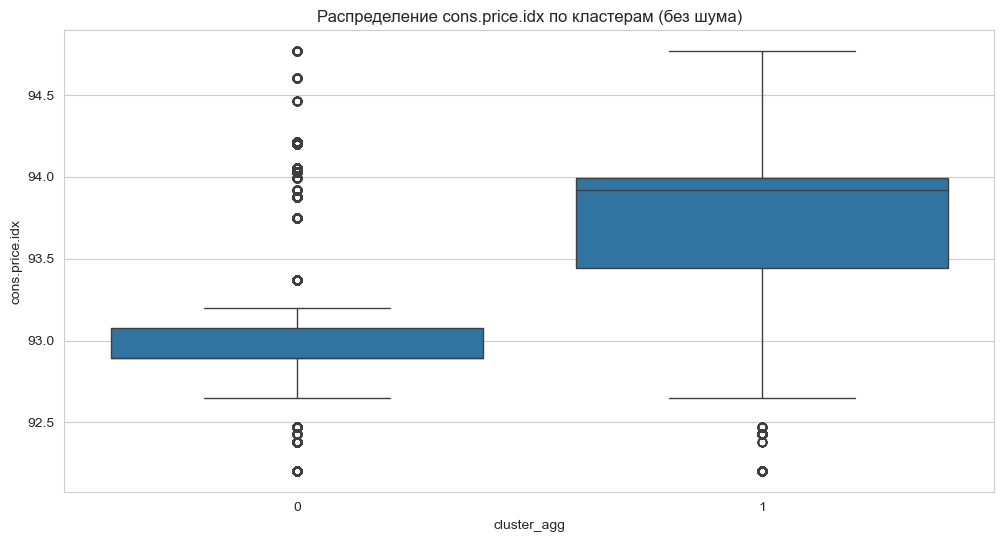

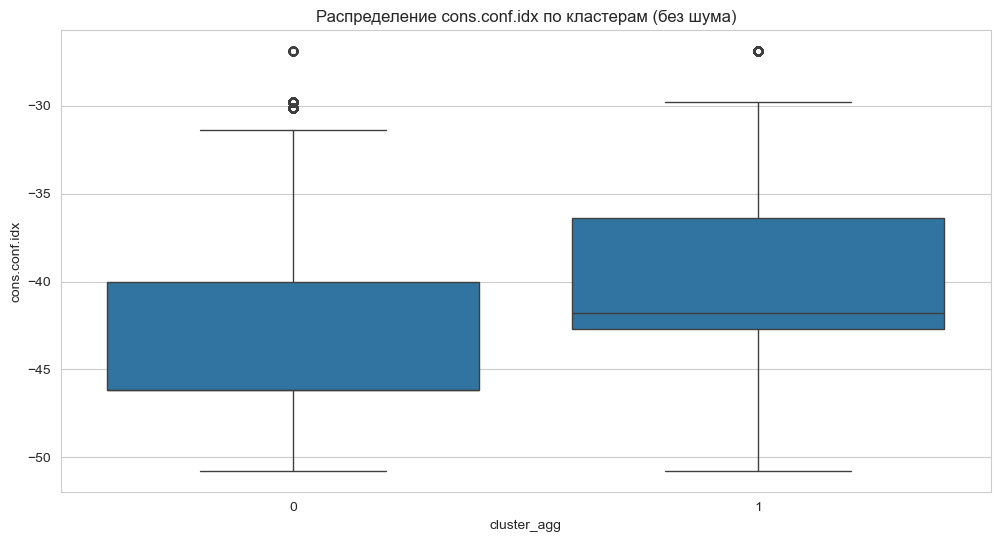

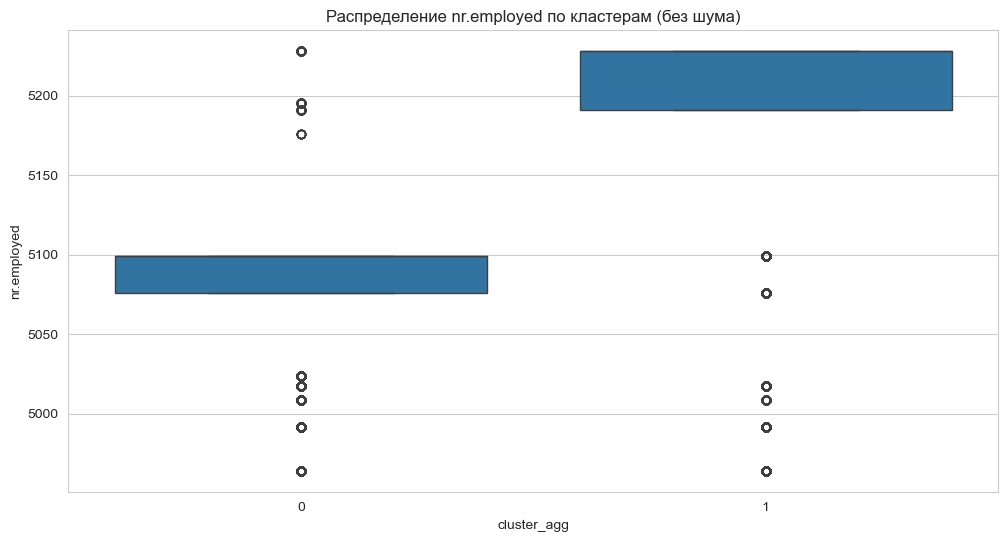


Средние значения one-hot признаков по кластерам (на исходных данных, без шума):
             job_blue-collar  job_entrepreneur  job_housemaid  job_management  \
cluster_agg                                                                     
0                       0.21              0.00           0.01            0.08   
1                       0.23              0.05           0.03            0.07   

             job_retired  job_self-employed  job_services  job_student  \
cluster_agg                                                              
0                   0.03               0.01          0.11         0.08   
1                   0.05               0.04          0.09         0.00   

             job_technician  job_unemployed  ...  month_may  month_nov  \
cluster_agg                                  ...                         
0                      0.16            0.01  ...       0.46       0.04   
1                      0.16            0.03  ...       0.29       0.12   



In [35]:
for col in numeric_cols:
    plt.figure()
    sns.boxplot(data=df_no_noise, x='cluster_agg', y=col)
    plt.title(f'Распределение {col} по кластерам (без шума)')
    plt.show()

cat_cols = [col for col in df.columns if col not in numeric_cols + ['cluster_agg']]
cluster_cat_profile = df_no_noise.groupby('cluster_agg')[cat_cols].mean()
print("\nСредние значения one-hot признаков по кластерам (на исходных данных, без шума):")
print(cluster_cat_profile.round(2))

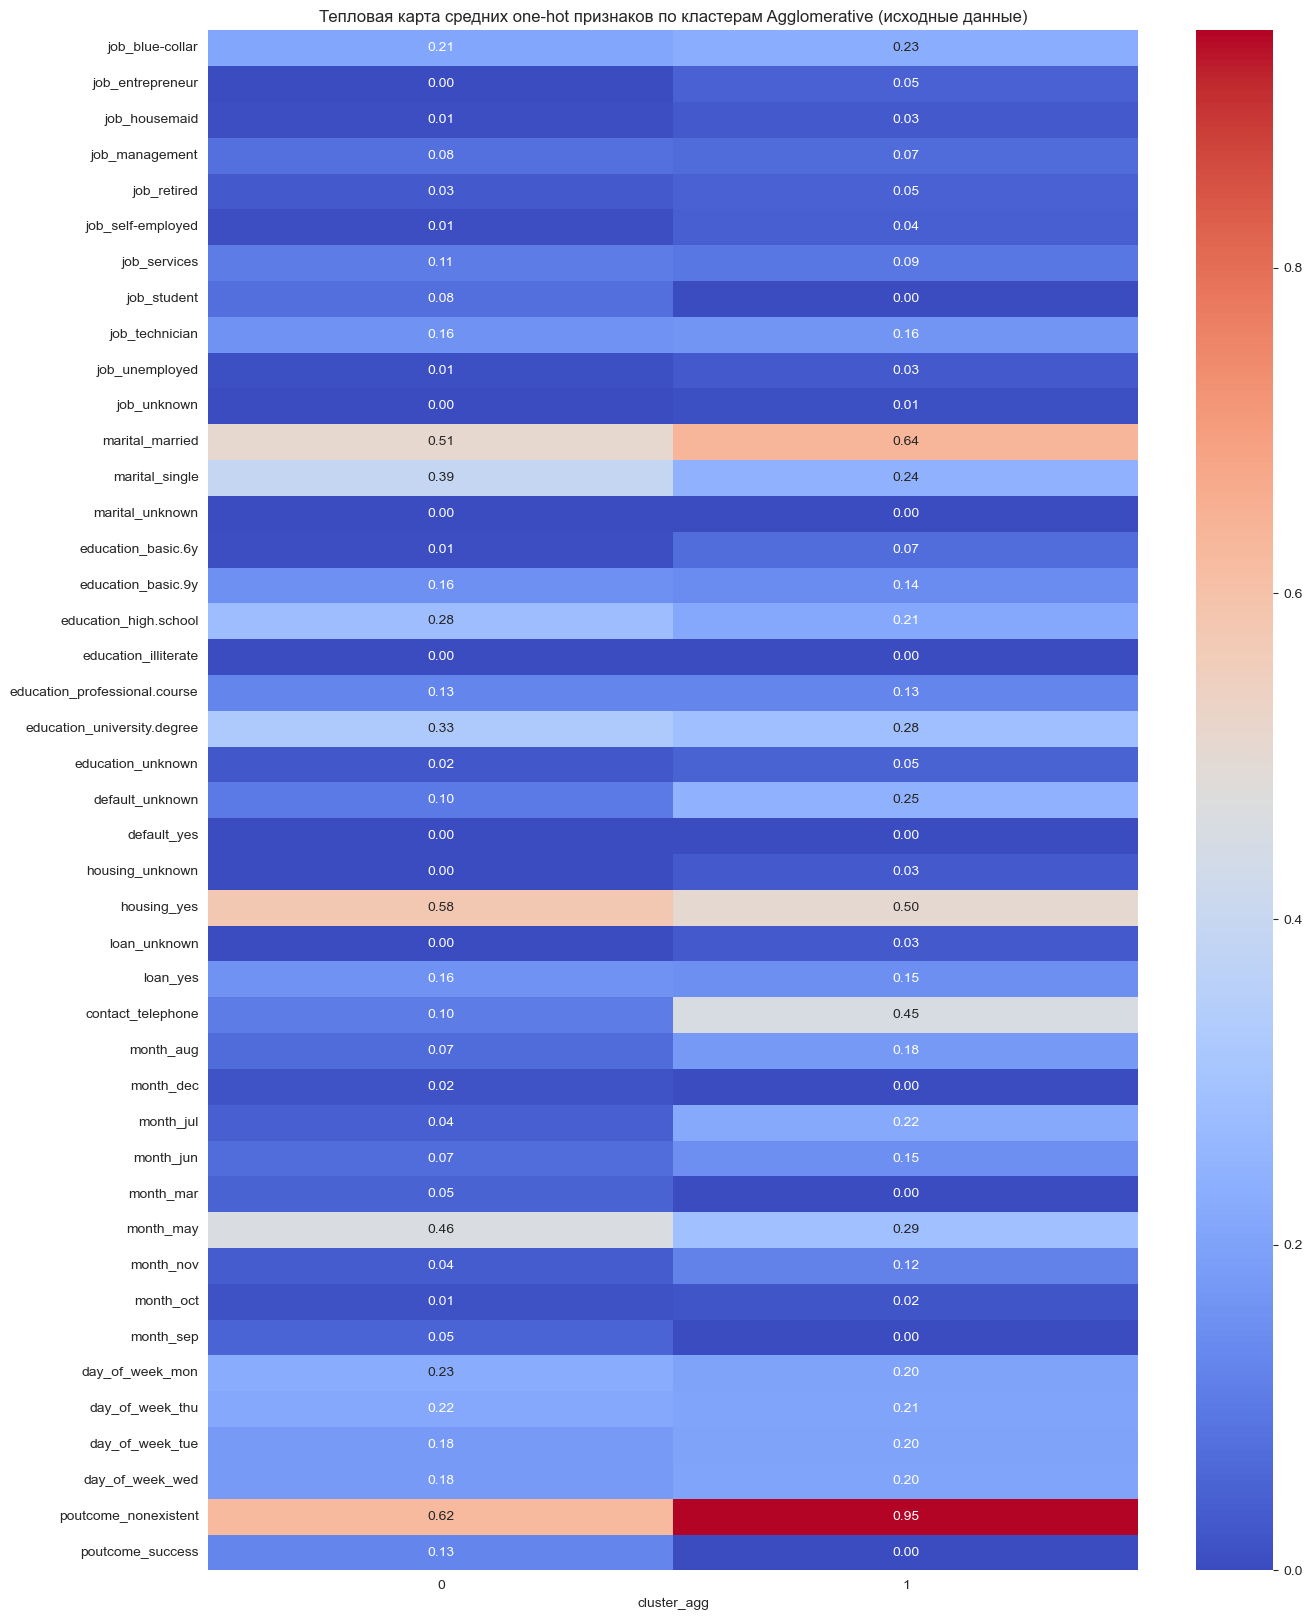

In [36]:
plt.figure(figsize=(15, 20))
sns.heatmap(cluster_cat_profile.T, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Тепловая карта средних one-hot признаков по кластерам Agglomerative (исходные данные)')
plt.show()